# 확장 2 — 미국 신호의 실행 활용
원 분석: `shipbuilding_crossasset.ipynb` Part F, `shipbuilding_F_extension.ipynb`. 이 노트북은 **기존 노트북과 결과 파일을 읽기만 하고**, 결과는 `results/ext2/`에 저장합니다.

- 주가: 네이버 수정주가(pykrx), KOSPI: FDR `KS11`, 미국: yfinance(`auto_adjust=True`) — 원 Part F와 같음
- 신호·바스켓·시점 정렬·수익률 필터 함수는 원 Part F에서 그대로 복사함 (아래 "원 Part F 코드" 셀)
- 표본: 2015-01 ~ 2026-09-17 (원 Part F와 같음)
- 모든 파라미터는 셀 1에 고정. 결과를 본 뒤 바꾸지 않음.

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 60)
plt.rcParams["figure.dpi"] = 110

RES_DIR = os.path.join("results", "ext2"); os.makedirs(RES_DIR, exist_ok=True)
START = "2015-01-01"
END   = "2026-09-25"          # 원 Part F 실행일 (재현용)
F_END = "2026-09-17"          # 원 Part F 표본의 마지막 날

# ---- 원 Part F 설정 그대로 ----
SHIP     = {"329180": "HD HHI", "010620": "HD Mipo", "010140": "Samsung HI", "042660": "Hanwha Ocean"}
SHIP_ALL = {"009540": "HD KSOE", **SHIP}
US_SIGNAL  = {"LNG": "Cheniere (US LNG exporter)", "HII": "Huntington Ingalls (US shipbuilder)",
              "ZIM": "ZIM (container shipping)"}
US_EXTRA   = {"BZ=F": "Brent crude"}
US_CONTROL = {"^GSPC": "S&P 500"}

# ---- 작업 1 파라미터 (고정) ----
MIN_PERIODS = 250             # 신호 백분위: 확장 창, 최소 250일
WEAK   = 0.2                  # 백분위 < 0.2 → 약한 날 (매수를 종가로 미룸)
STRONG = 0.8                  # 백분위 ≥ 0.8 → 강한 날 (보조: 매도를 종가로 미룸) — 원 F3 신호일과 같은 기준
HAC_LAG = 5
N_PLACEBO = 5000
SEED = 20260930               # 플라시보 난수 시드 (재현용)
SPLIT = "2020-12-31"          # 전·후반 분리

In [2]:
# ---- 원 Part F 코드 (shipbuilding_crossasset.ipynb에서 그대로 복사) ----
def load_ohlc(ticker, start, end):
    s, e = start.replace("-", ""), end.replace("-", "")
    try:
        from pykrx import stock
        df = stock.get_market_ohlcv(s, e, ticker)
        if df is not None and not df.empty:
            df = df.rename(columns={"시가": "Open", "종가": "Close", "거래량": "Volume"})
            return df[["Open", "Close", "Volume"]].astype(float)
    except Exception as ex:
        print(f"  pykrx 실패({ticker}): {ex}")
    try:
        import FinanceDataReader as fdr
        df = fdr.DataReader(ticker, start, end)
        if df is not None and not df.empty:
            print(f"  FDR 사용({ticker})")
            return df[["Open", "Close", "Volume"]].astype(float)
    except Exception as ex:
        print(f"  FDR 실패({ticker}): {ex}")
    return None

def load_panel(names, start, end):
    O, C, V = {}, {}, {}
    for t in names:
        df = load_ohlc(t, start, end)
        if df is None:
            print(f"  -> {t} 제외"); continue
        df.index = pd.to_datetime(df.index)
        O[t], C[t], V[t] = df["Open"], df["Close"], df["Volume"]
        time.sleep(0.3)
    return pd.DataFrame(O), pd.DataFrame(C), pd.DataFrame(V)

def kr_returns(O, C, V, cap=0.305):
    halt = (V == 0) | V.isna() | (O <= 0)
    cc = C.pct_change(fill_method=None)
    gap = O / C.shift(1) - 1
    intra = C / O - 1
    bad = halt | (cc.abs() > cap) | (gap.abs() > cap) | (intra.abs() > cap)
    n_bad = int((bad & ~halt).values.sum())
    if n_bad:
        print(f"  비정상 수익률 {n_bad}개 NaN 처리 (수정주가 기준 불일치 가능 → 확인 필요)")
    return cc.mask(bad), gap.mask(bad), intra.mask(bad)

def basket(df, cols):
    cols = [c for c in cols if c in df.columns]
    return df[cols].mean(axis=1, skipna=True)

def align_us_to_kr(us_ret, kr_dates):
    us_idx = us_ret.index
    out = np.full((len(kr_dates), us_ret.shape[1]), np.nan)
    prev = kr_dates[0] - pd.Timedelta(days=5)
    for i, k in enumerate(kr_dates):
        m = (us_idx >= prev) & (us_idx < k)
        if m.any():
            out[i] = us_ret.loc[m].sum(min_count=1).values
        prev = k
    return pd.DataFrame(out, index=kr_dates, columns=us_ret.columns)

def hac_ols(y, X, lags=5):
    d = pd.concat([y, X], axis=1).dropna()
    res = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1:])).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res

def metrics(r, name=""):
    r = r.dropna()
    if len(r) < 60: return {"strategy": name}
    yrs = len(r) / 252; cum = (1 + r).prod()
    cagr = cum ** (1 / yrs) - 1; vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod(); mdd = (eq / eq.cummax() - 1).min()
    return {"strategy": name, "CAGR(%)": cagr * 100, "Vol(%)": vol * 100,
            "Sharpe": cagr / vol if vol > 0 else np.nan, "MDD(%)": mdd * 100, "Days": len(r)}

In [3]:
# ---- 데이터 (원 Part F와 같은 방식) + 원 결과 재현 확인 ----
import FinanceDataReader as fdr
kospi = fdr.DataReader("KS11", START, END)[["Open", "Close"]].astype(float)   # 지수는 FDR (원 Part F도 pykrx 지수 실패 후 FDR 사용)
kospi.index = pd.to_datetime(kospi.index); kospi = kospi.loc[:F_END]
CAL = kospi.index
O, C, V = load_panel(SHIP_ALL, START, END)
PANEL = (O.reindex(CAL), C.reindex(CAL), V.reindex(CAL))
Rs = kr_returns(*PANEL)
k_cc    = kospi["Close"].pct_change(fill_method=None)
k_gap   = kospi["Open"] / kospi["Close"].shift(1) - 1
k_intra = kospi["Close"] / kospi["Open"] - 1
ship_cols = list(SHIP.keys())
B = pd.DataFrame({"ship_cc_ex": basket(Rs[0], ship_cols) - k_cc,
                  "ship_gap_ex": basket(Rs[1], ship_cols) - k_gap,
                  "ship_intra_ex": basket(Rs[2], ship_cols) - k_intra,
                  "ship_intra": basket(Rs[2], ship_cols), "kospi_cc": k_cc})

import yfinance as yf
us_tickers = list(US_SIGNAL) + list(US_EXTRA) + list(US_CONTROL)
raw_us = yf.download(us_tickers, start=START, end=END, auto_adjust=True, progress=False)["Close"]
if isinstance(raw_us, pd.Series):
    raw_us = raw_us.to_frame(us_tickers[0])
raw_us.index = pd.to_datetime(raw_us.index).tz_localize(None)
for t in [c for c in us_tickers if c not in raw_us.columns or raw_us[c].notna().sum() == 0]:
    for _ in range(3):
        time.sleep(2)
        s = yf.download(t, start=START, end=END, auto_adjust=True, progress=False)["Close"]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        if s.notna().sum() > 0:
            s.index = pd.to_datetime(s.index).tz_localize(None); raw_us[t] = s; break
    assert raw_us[t].notna().sum() > 0, f"{t} 데이터 수신 실패"
us_ret = np.log(raw_us).apply(lambda s: s.dropna().diff()).reindex(raw_us.index)
usk = align_us_to_kr(us_ret, CAL)
sig_cols = [c for c in US_SIGNAL if c in usk.columns]
F = B.copy()
F["us_ship"] = usk[sig_cols].mean(axis=1, skipna=True)
F["spx"] = usk["^GSPC"]; F["brent"] = usk["BZ=F"]
F["signal"] = F["us_ship"] - F["spx"]

res2 = hac_ols(F["ship_intra_ex"], F[["us_ship", "spx", "brent"]])
orig = pd.read_csv("results_cross/F1_regression.csv").set_index(["target", "var"])     # 읽기만 함
print(f"F2 재현: us_ship coef {res2.params['us_ship']:.4f}, t {res2.tvalues['us_ship']:.2f}, N {int(res2.nobs)} "
      f"(원본 {orig.loc[('ship_intra_ex','us_ship'),'coef']:.4f}, t {orig.loc[('ship_intra_ex','us_ship'),'HAC t']:.2f}, "
      f"N {int(orig.loc[('ship_intra_ex','us_ship'),'N'])})")
rank = F["signal"].expanding(min_periods=MIN_PERIODS).rank(pct=True)
on = (rank >= 0.8).astype(float)
print(f"F3 재현: 신호일 {int(on.sum())}일, 신호일 평균 장중 수익 {F.loc[on > 0, 'ship_intra'].mean()*100:.3f}% (원 보고서 598일, 0.236%)")
m_f3 = metrics(F["ship_intra"].fillna(0), "매일 시가→종가")          # 원 F3와 같은 방식 (NaN일 = 0)
m_all = metrics(F["ship_intra"].where(rank.notna()), "매일 시가→종가")
print(f"매일 시가→종가(비용 전) CAGR: 전체 {m_f3['Days']}일 {m_f3['CAGR(%)']:.1f}% (원 F3 −18.8%, 2,875일) / "
      f"레짐 판정 가능일 {m_all['Days']}일 {m_all['CAGR(%)']:.1f}%")
print(f"  같은 기간 산술 평균 장중 수익 {F['ship_intra'].where(rank.notna()).mean()*1e4:.2f}bp/일, 장중 변동성 {m_all['Vol(%)']:.1f}%/년 "
      f"→ CAGR의 상당 부분은 변동성 손실(≈ σ²/2)")

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


F2 재현: us_ship coef 0.1029, t 3.68, N 2780 (원본 0.1029, t 3.68, N 2780)
F3 재현: 신호일 598일, 신호일 평균 장중 수익 0.236% (원 보고서 598일, 0.236%)
매일 시가→종가(비용 전) CAGR: 전체 2875일 -18.8% (원 F3 −18.8%, 2,875일) / 레짐 판정 가능일 2533일 -13.8%
  같은 기간 산술 평균 장중 수익 -3.27bp/일, 장중 변동성 36.5%/년 → CAGR의 상당 부분은 변동성 손실(≈ σ²/2)


---
## 작업 1. 미국 신호를 체결 타이밍 도구로 쓸 때 비용 없이 매수 단가를 낮추는가
**가설**: 미국 밤사이 신호가 약한 날엔 조선주 장중 수익이 낮으므로, 그날 매수를 종가로 미루면 매수 단가가 낮아진다. 추가 거래가 없으므로 거래비용은 0이다.

- 신호 = LNG·HII·ZIM 평균 − S&P500 (한국 시가 전 공개분), 강도 = 확장 백분위(최소 250일). 백분위가 없는 날(초기 250일)은 제외.
- 투자자: 매 거래일 바스켓 4종목을 같은 금액씩 매수 (종목별 계산 후 평균)
  - **B1** 항상 시가 매수 / **B2** 항상 종가 매수 / **S** 백분위 < 0.2면 종가, 그 외 시가
- 절감(bp) = (벤치마크 체결가 − 전략 체결가) / 벤치마크 체결가 × 10,000, 매수일 전체 평균
  - S vs B1: 약한 날만 (시가 − 종가)/시가, 나머지 0 / S vs B2: 약한 날이 아닌 날만 (종가 − 시가)/종가, 나머지 0
- **판정 (미리 정함)**: S vs B1 절감이, 약한 날과 같은 수의 날을 무작위로 골라 종가로 미룬 5,000번 플라시보 분포의 상위 5% 밖(단측 p < 0.05)이면 지지. 그 안이면 "종가가 원래 싸서 생긴 절감"으로 보고.
- 가격: 수정주가의 같은 날 시가·종가 비율 = 실제 낸 가격의 비율(수정 비율이 시가·종가에 같게 적용된 날). 어긋난 날은 강건성의 "제외 후"에서 뺌.

In [4]:
# ---- 1-0. 분석일, 약한/강한 날, 종목별 장중 수익률 ----
INTRA = Rs[2][ship_cols]                                  # 원 Part F 필터(거래정지·±30.5% 초과 NaN) 적용된 종목별 시가→종가
ANAL = rank.notna() & INTRA.notna().any(axis=1)           # 레짐 판정 가능 + 바스켓 중 1종목 이상 거래
weak = (rank < WEAK) & ANAL
strong = (rank >= STRONG) & ANAL
print(f"분석일 {int(ANAL.sum())}일 ({ANAL[ANAL].index.min().date()} ~ {ANAL[ANAL].index.max().date()}), "
      f"약한 날 {int(weak.sum())}일 ({weak.sum()/ANAL.sum()*100:.1f}%), 강한 날 {int(strong.sum())}일 ({strong.sum()/ANAL.sum()*100:.1f}%)")

# F 확장 Step 1의 의심 종목·일 (1-2 수정 비율 불일치 + 1-3 재개일·수정 이벤트 ±1일) — 결과 CSV에서 읽기만 함
_m = pd.read_csv("results/F_ext/S1_2_adjust_ratio_mismatch_days.csv", dtype={"code": str}, parse_dates=["date"])
_r = pd.read_csv("results/F_ext/S1_3_resume_corpaction_gaps.csv", parse_dates=["date"])
_name2code = {v: k for k, v in SHIP.items()}
EXC = pd.DataFrame(False, index=CAL, columns=ship_cols)
for c, d in list(zip(_m["code"], _m["date"])) + list(zip(_r["종목"].map(_name2code), _r["date"])):
    EXC.loc[d, c] = True
print(f"의심 종목·일: {int(EXC.values.sum())}개 (F 확장 보고 439개)")
assert int(EXC.values.sum()) == 439
print(f"그중 분석일·유효 수익률에 걸리는 것: {int((EXC & INTRA.notna() & ANAL.values[:, None]).values.sum())}개")

# 맥락: 약한 날 / 그 외 / 강한 날의 바스켓 장중 수익률(bp)
ctx = pd.DataFrame([{"구분": lab, "일수": int(m.sum()), "바스켓 장중 평균(bp)": F.loc[m, "ship_intra"].mean() * 1e4,
                     "KOSPI 장중 평균(bp)": k_intra[m].mean() * 1e4, "초과 장중 평균(bp)": F.loc[m, "ship_intra_ex"].mean() * 1e4}
                    for lab, m in [("전체 분석일", ANAL), ("약한 날 (<0.2)", weak), ("그 외 (≥0.2)", ANAL & ~weak), ("강한 날 (≥0.8)", strong)]]).set_index("구분")
ctx.to_csv(f"{RES_DIR}/T1_0_intraday_by_signal.csv", encoding="utf-8-sig"); display(ctx)

분석일 2533일 (2016-01-15 ~ 2026-09-17), 약한 날 554일 (21.9%), 강한 날 598일 (23.6%)
의심 종목·일: 439개 (F 확장 보고 439개)
그중 분석일·유효 수익률에 걸리는 것: 284개


,일수,바스켓 장중 평균(bp),KOSPI 장중 평균(bp),초과 장중 평균(bp)
구분,,,,
전체 분석일,2533,-3.2651,-3.7473,0.4822
약한 날 (<0.2),554,-38.5615,-7.9352,-30.6263
그 외 (≥0.2),1979,6.6157,-2.5749,9.1907
강한 날 (≥0.8),598,23.6421,-3.8480,27.4901


In [5]:
# ---- 1-1. 절감 계산과 플라시보 ----
def hac_mean(x, lags=HAC_LAG):
    x = np.asarray(x, float)
    r = sm.OLS(x, np.ones(len(x))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return float(r.params[0]), float(r.tvalues[0]), float(r.pvalues[0])

def placebo(x, k, R=N_PLACEBO, seed=SEED):
    """x: 날짜별 '벤치마크에서 벗어났을 때' 절감(bp). k일을 무작위로 골라 벗어남 → 전체 평균 절감 분포."""
    rng = np.random.default_rng(seed); x = np.asarray(x, float); N = len(x)
    return np.array([x[rng.choice(N, k, replace=False)].sum() / N for _ in range(R)])

def evaluate(intra, days, flag, side="buy", kospi_intra=None, label=""):
    """intra: 종목별 시가→종가 수익률(필터·제외 적용). flag: 종가로 미루는 날(매수: 약한 날, 매도: 강한 날).
    매수: vs B1 절감 = (O−C)/O = −r,  vs B2 절감 = (C−O)/C = r/(1+r)
    매도: vs B1 절감 = (C−O)/O = r,   vs B2 절감 = (O−C)/C = −r/(1+r)     (r = C/O − 1, 종목별 계산 후 평균)"""
    sgn = 1 if side == "buy" else -1
    dA = (-sgn * intra).mean(axis=1)                    # 종가로 미뤘을 때 vs 항상 시가
    dB = (sgn * intra / (1 + intra)).mean(axis=1)       # 시가로 당겼을 때 vs 항상 종가
    if kospi_intra is not None:                         # KOSPI 대비 초과 기준 (보조)
        dA = dA + sgn * kospi_intra
        dB = dB - sgn * kospi_intra / (1 + kospi_intra)
    d = days & dA.notna()
    dA, dB, fl = dA[d] * 1e4, dB[d] * 1e4, flag[d].astype(bool)
    N, k = len(dA), int(fl.sum())
    out, sims = [], {}
    m, t, p = hac_mean(dA)
    out.append({"표본": label, "비교": "B2 vs B1 (항상 종가 vs 항상 시가)", "분석일": N, "종가로 미룬 날": N,
                "평균 절감(bp)": m, "HAC t": t, "p (양측)": p, "절감 발생일 평균(bp)": dA.mean()})
    sA = dA.where(fl, 0.0); m, t, p = hac_mean(sA)
    sims["A"] = placebo(dA.values, k)
    out.append({"표본": label, "비교": "S vs B1 (항상 시가)", "분석일": N, "종가로 미룬 날": k,
                "평균 절감(bp)": m, "HAC t": t, "p (양측)": p, "절감 발생일 평균(bp)": dA[fl].mean(),
                "플라시보 평균(bp)": sims["A"].mean(), "플라시보 95% 분위(bp)": np.percentile(sims["A"], 95),
                "플라시보 백분위": (sims["A"] < m).mean() * 100, "플라시보 단측 p": (1 + (sims["A"] >= m).sum()) / (N_PLACEBO + 1)})
    sB = dB.where(~fl, 0.0); m, t, p = hac_mean(sB)
    sims["B"] = placebo(dB.values, N - k)
    out.append({"표본": label, "비교": "S vs B2 (항상 종가)", "분석일": N, "종가로 미룬 날": k,
                "평균 절감(bp)": m, "HAC t": t, "p (양측)": p, "절감 발생일 평균(bp)": dB[~fl].mean(),
                "플라시보 평균(bp)": sims["B"].mean(), "플라시보 95% 분위(bp)": np.percentile(sims["B"], 95),
                "플라시보 백분위": (sims["B"] < m).mean() * 100, "플라시보 단측 p": (1 + (sims["B"] >= m).sum()) / (N_PLACEBO + 1)})
    return pd.DataFrame(out), sims

T_main, SIM_main = evaluate(INTRA, ANAL, weak, "buy", label="전체")
display(T_main.set_index("비교").drop(columns="표본"))
row = T_main.set_index("비교").loc["S vs B1 (항상 시가)"]
SUPPORT = row["플라시보 단측 p"] < 0.05
print(f"S vs B1 절감 {row['평균 절감(bp)']:.2f}bp, 플라시보 평균 {row['플라시보 평균(bp)']:.2f}bp, "
      f"백분위 {row['플라시보 백분위']:.1f}, 단측 p {row['플라시보 단측 p']:.4f} ⇒ "
      + ("신호가 무작위보다 유의하게 절감 (지지)" if SUPPORT else "무작위 연기와 구별 안 됨 — 절감은 '종가가 원래 싸서' 생긴 것"))

,분석일,종가로 미룬 날,평균 절감(bp),HAC t,p (양측),절감 발생일 평균(bp),플라시보 평균(bp),플라시보 95% 분위(bp),플라시보 백분위,플라시보 단측 p
비교,,,,,,,,,,
B2 vs B1 (항상 종가 vs 항상 시가),2533,2533,3.2651,0.7492,0.4537,3.2651,NaN,NaN,NaN,NaN
S vs B1 (항상 시가),2533,554,8.4339,4.1190,0.0000,38.5615,0.7310,3.8176,100.0000,0.0002
S vs B2 (항상 종가),2533,554,-0.5879,-0.1549,0.8769,-0.7525,-8.2823,-5.1776,100.0000,0.0002


S vs B1 절감 8.43bp, 플라시보 평균 0.73bp, 백분위 100.0, 단측 p 0.0002 ⇒ 신호가 무작위보다 유의하게 절감 (지지)


In [6]:
# ---- 1-2. 강건성: 전·후반, 의심 관측치 제외, KOSPI 초과 기준, 매도 버전 ----
TAB, SIMS = [T_main], {"전체": SIM_main}
first = ANAL & (ANAL.index <= SPLIT); second = ANAL & (ANAL.index > SPLIT)
for lab, dm in [(f"전반 (~{SPLIT})", first), (f"후반 ({SPLIT[:4]}-12-31 이후)", second)]:
    t_, s_ = evaluate(INTRA, dm, weak, "buy", label=lab); TAB.append(t_); SIMS[lab] = s_
INTRA_x = INTRA.mask(EXC)
t_, s_ = evaluate(INTRA_x, ANAL & INTRA_x.notna().any(axis=1), weak, "buy", label="의심 439개 제외"); TAB.append(t_); SIMS["제외"] = s_
t_, s_ = evaluate(INTRA, ANAL, weak, "buy", kospi_intra=k_intra, label="(보조) KOSPI 대비 초과 기준"); TAB.append(t_); SIMS["초과"] = s_
T1 = pd.concat(TAB, ignore_index=True)
T1.to_csv(f"{RES_DIR}/T1_1_buy_savings.csv", index=False, encoding="utf-8-sig")
display(T1.set_index(["표본", "비교"]))

# (보조) 매도 버전: 강한 날(≥0.8) 종가 매도, 그 외 시가 매도
T_sell, SIM_sell = evaluate(INTRA, ANAL, strong, "sell", label="(보조) 매도 — 전체")
T_sell["비교"] = T_sell["비교"].str.replace("항상 종가 vs 항상 시가", "항상 종가 매도 vs 항상 시가 매도")
T_sell_x, _ = evaluate(INTRA_x, ANAL & INTRA_x.notna().any(axis=1), strong, "sell", label="(보조) 매도 — 의심 439개 제외")
T1s = pd.concat([T_sell, T_sell_x], ignore_index=True)
T1s.to_csv(f"{RES_DIR}/T1_2_sell_savings.csv", index=False, encoding="utf-8-sig")
display(T1s.set_index(["표본", "비교"]))

# 요약 표 (S vs B1 중심)
key = T1[T1["비교"].str.startswith("S vs B1")][["표본", "분석일", "종가로 미룬 날", "평균 절감(bp)", "HAC t", "절감 발생일 평균(bp)",
                                               "플라시보 평균(bp)", "플라시보 백분위", "플라시보 단측 p"]]
key = pd.concat([key, T1s[T1s["비교"].str.startswith("S vs B1")][key.columns]], ignore_index=True)
key["판정 (단측 p < 0.05)"] = np.where(key["플라시보 단측 p"] < 0.05, "무작위보다 유의하게 절감", "무작위와 구별 안 됨")
key.to_csv(f"{RES_DIR}/T1_3_summary_S_vs_B1.csv", index=False, encoding="utf-8-sig"); display(key.set_index("표본"))

분석일  종가로 미룬 날  평균 절감(bp)   HAC t  p (양측)  절감 발생일 평균(bp)  플라시보 평균(bp)  플라시보 95% 분위(bp)  플라시보 백분위  플라시보 단측 p
표본                  비교                                                                                                                                    
전체                  B2 vs B1 (항상 종가 vs 항상 시가)  2533      2533     3.2651  0.7492  0.4537         3.2651          NaN              NaN       NaN        NaN
                    S vs B1 (항상 시가)            2533       554     8.4339  4.1190  0.0000        38.5615       0.7310           3.8176  100.0000     0.0002
                    S vs B2 (항상 종가)            2533       554    -0.5879 -0.1549  0.8769        -0.7525      -8.2823          -5.1776  100.0000     0.0002
전반 (~2020-12-31)    B2 vs B1 (항상 종가 vs 항상 시가)  1180      1180     3.5363  0.5975  0.5502         3.5363          NaN              NaN       NaN        NaN
                    S vs B1 (항상 시가)            1180       218     5.5846  2.0244  0.0429        30.2284       0.6900           4.9258   97.1000     0.0292
                    S vs B2 (항상 종가)            1180       218    -3.4055 -0.6631  0.5073        -4.1773      -8.3426          -4.1831   97.4400     0.0258
후반 (2020-12-31 이후)  B2 vs B1 (항상 종가 vs 항상 시가)  1353      1353     3.0286  0.4794  0.6317         3.0286          NaN              NaN       NaN        NaN
                    S vs B1 (항상 시가)            1353       336    10.9189  3.6716  0.0002        43.9681       0.8252           5.4894   99.9800     0.0004
                    S vs B2 (항상 종가)            1353       336     1.8694  0.3392  0.7345         2.4870      -8.2180          -3.5593  100.0000     0.0002
의심 439개 제외          B2 vs B1 (항상 종가 vs 항상 시가)  2533      2533     3.1428  0.7125  0.4761         3.1428          NaN              NaN       NaN        NaN
                    S vs B1 (항상 시가)            2533       554     8.2903  3.9775  0.0001        37.9051       0.7062           3.8702  100.0000     0.0002
                    S vs B2 (항상 종가)            2533       554    -0.5738 -0.1494  0.8812        -0.7344      -8.1739          -5.0422   99.9800     0.0004
(보조) KOSPI 대비 초과 기준 B2 vs B1 (항상 종가 vs 항상 시가)  2533      2533    -0.4822 -0.1222  0.9027        -0.4822          NaN              NaN       NaN        NaN
                    S vs B1 (항상 시가)            2533       554     6.6984  3.5062  0.0005        30.6263      -0.0928           2.7321  100.0000     0.0002
                    S vs B2 (항상 종가)            2533       554     2.3797  0.6948  0.4872         3.0459      -4.3775          -1.5936  100.0000     0.0002

분석일  종가로 미룬 날  평균 절감(bp)   HAC t  p (양측)  절감 발생일 평균(bp)  플라시보 평균(bp)  플라시보 95% 분위(bp)  플라시보 백분위  플라시보 단측 p
표본                   비교                                                                                                                                          
(보조) 매도 — 전체         B2 vs B1 (항상 종가 매도 vs 항상 시가 매도)  2533      2533    -3.2651 -0.7492  0.4537        -3.2651          NaN              NaN       NaN        NaN
                     S vs B1 (항상 시가)                  2533       598     5.5815  2.3916  0.0168        23.6421      -0.7549           2.4133   99.9200     0.0010
                     S vs B2 (항상 종가)                  2533       598    14.1588  3.8643  0.0001        18.5345       8.1613          11.3389   99.8400     0.0018
(보조) 매도 — 의심 439개 제외 B2 vs B1 (항상 종가 vs 항상 시가)        2533      2533    -3.1428 -0.7125  0.4761        -3.1428          NaN              NaN       NaN        NaN
                     S vs B1 (항상 시가)                  2533       598     5.2621  2.2385  0.0252        22.2890      -0.7317           2.4763   99.8600     0.0016
                     S vs B2 (항상 종가)                  2533       598    13.7140  3.7049  0.0002        17.9522       8.0577          11.2912   99.7400     0.0028

,분석일,종가로 미룬 날,평균 절감(bp),HAC t,절감 발생일 평균(bp),플라시보 평균(bp),플라시보 백분위,플라시보 단측 p,판정 (단측 p < 0.05)
표본,,,,,,,,,
전체,2533,554,8.4339,4.1190,38.5615,0.7310,100.0000,0.0002,무작위보다 유의하게 절감
전반 (~2020-12-31),1180,218,5.5846,2.0244,30.2284,0.6900,97.1000,0.0292,무작위보다 유의하게 절감
후반 (2020-12-31 이후),1353,336,10.9189,3.6716,43.9681,0.8252,99.9800,0.0004,무작위보다 유의하게 절감
의심 439개 제외,2533,554,8.2903,3.9775,37.9051,0.7062,100.0000,0.0002,무작위보다 유의하게 절감
(보조) KOSPI 대비 초과 기준,2533,554,6.6984,3.5062,30.6263,-0.0928,100.0000,0.0002,무작위보다 유의하게 절감
(보조) 매도 — 전체,2533,598,5.5815,2.3916,23.6421,-0.7549,99.9200,0.0010,무작위보다 유의하게 절감
(보조) 매도 — 의심 439개 제외,2533,598,5.2621,2.2385,22.2890,-0.7317,99.8600,0.0016,무작위보다 유의하게 절감


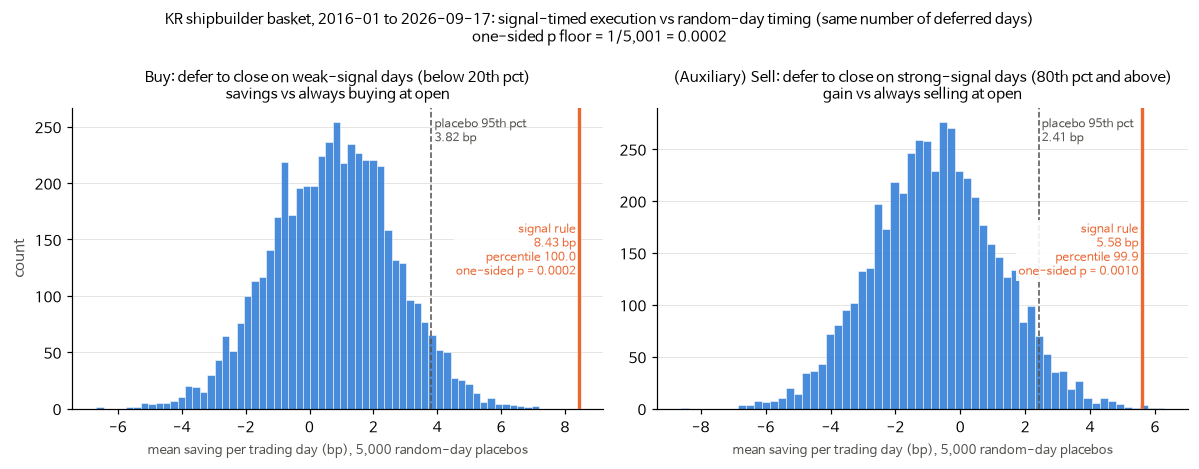

In [7]:
# ---- 1-3. 그림: 플라시보 절감 분포 + S ----
BLUE, ORANGE, INK, INK2, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e4e3df"
panels = [("Buy: defer to close on weak-signal days (below 20th pct)\nsavings vs always buying at open", SIM_main["A"],
           T_main.set_index("비교").loc["S vs B1 (항상 시가)"]),
          ("(Auxiliary) Sell: defer to close on strong-signal days (80th pct and above)\ngain vs always selling at open", SIM_sell["A"],
           T_sell.set_index("비교").loc["S vs B1 (항상 시가)"])]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, (title, sims, r) in zip(axes, panels):
    ax.hist(sims, bins=60, color=BLUE, alpha=0.85, edgecolor="white", linewidth=0.4, zorder=2)
    q95 = np.percentile(sims, 95)
    ax.axvline(q95, color=INK2, lw=1, ls="--", zorder=3)
    ax.axvline(r["평균 절감(bp)"], color=ORANGE, lw=2.2, zorder=6)
    ymax = ax.get_ylim()[1]
    ax.text(q95, ymax * 0.97, " placebo 95th pct\n %.2f bp" % q95, color=INK2, fontsize=8, va="top", ha="left")
    ax.set_xlim(right=max(ax.get_xlim()[1], r["평균 절감(bp)"] + 0.6))
    ax.text(r["평균 절감(bp)"], ymax * 0.62, "signal rule \n%.2f bp \npercentile %.1f \none-sided p = %.4f " % (r["평균 절감(bp)"], r["플라시보 백분위"], r["플라시보 단측 p"]),
            color=ORANGE, fontsize=8, va="top", ha="right", zorder=5, bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5))
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel("mean saving per trading day (bp), 5,000 random-day placebos", color=INK2, fontsize=8.5)
    ax.grid(axis="y", color=GRID, lw=0.6, zorder=0); ax.set_axisbelow(True)
    for s_ in ["top", "right"]: ax.spines[s_].set_visible(False)
axes[0].set_ylabel("count", color=INK2)
fig.suptitle("KR shipbuilder basket, 2016-01 to 2026-09-17: signal-timed execution vs random-day timing (same number of deferred days)\n"
             "one-sided p floor = 1/5,001 = 0.0002", fontsize=10)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_ext2_overlay.png", bbox_inches="tight"); plt.show()

In [8]:
# ---- 1-4. 검정 수와 다중검정 기준 ----
tests = []
for _, r in pd.concat([T1, T1s]).iterrows():
    tests.append({"표본": r["표본"], "비교": r["비교"], "검정": "HAC t (평균 절감 = 0)", "p": r["p (양측)"]})
    if pd.notna(r.get("플라시보 단측 p")):
        tests.append({"표본": r["표본"], "비교": r["비교"], "검정": "플라시보 (단측)", "p": r["플라시보 단측 p"]})
TT = pd.DataFrame(tests)
TT["사전 지정 판정 검정"] = (TT["표본"] == "전체") & TT["비교"].str.startswith("S vs B1") & (TT["검정"] == "플라시보 (단측)")
NT = len(TT)
TT.to_csv(f"{RES_DIR}/T1_4_test_count.csv", index=False, encoding="utf-8-sig")
print(f"작업 1 보고 검정 수: {NT}개 → Bonferroni 기준 p < {0.05/NT:.5f}")
print(f"사전 지정 판정 검정 1개 (전체 · S vs B1 · 플라시보): p = {TT.loc[TT['사전 지정 판정 검정'], 'p'].iloc[0]:.4f} (단독 기준 0.05)")
print(f"Bonferroni 통과 검정: {int((TT['p'] < 0.05/NT).sum())}개")
display(TT[TT["p"] < 0.05/NT])

작업 1 보고 검정 수: 35개 → Bonferroni 기준 p < 0.00143
사전 지정 판정 검정 1개 (전체 · S vs B1 · 플라시보): p = 0.0002 (단독 기준 0.05)
Bonferroni 통과 검정: 15개


,표본,비교,검정,p,사전 지정 판정 검정
1,전체,S vs B1 (항상 시가),HAC t (평균 절감 = 0),0.0000,False
2,전체,S vs B1 (항상 시가),플라시보 (단측),0.0002,True
4,전체,S vs B2 (항상 종가),플라시보 (단측),0.0002,False
11,후반 (2020-12-31 이후),S vs B1 (항상 시가),HAC t (평균 절감 = 0),0.0002,False
12,후반 (2020-12-31 이후),S vs B1 (항상 시가),플라시보 (단측),0.0004,False
14,후반 (2020-12-31 이후),S vs B2 (항상 종가),플라시보 (단측),0.0002,False
16,의심 439개 제외,S vs B1 (항상 시가),HAC t (평균 절감 = 0),0.0001,False
17,의심 439개 제외,S vs B1 (항상 시가),플라시보 (단측),0.0002,False
19,의심 439개 제외,S vs B2 (항상 종가),플라시보 (단측),0.0004,False
21,(보조) KOSPI 대비 초과 기준,S vs B1 (항상 시가),HAC t (평균 절감 = 0),0.0005,False


---
## 작업 2. 수주 공시를 보고 실제로 살 수 있는 사람이 얻는 수익
**배경**: Part B의 [0,+1] CAR +0.68%는 공시 당일(t0)을 포함한 상한임. 공시 시각이 없어 장중·장 마감 후 공시를 구분할 수 없으므로, 모든 공시에서 **t0 다음 거래일(t1) 시가에 산다**고 보수적으로 가정함.

설정 (고정)
- 이벤트: Part B와 같은 원공시 기준 이벤트(같은 종목·같은 날 묶음, CAR 계산 가능 627개). `outputs/events_with_car.csv`를 읽기만 하고, Part B 코드로 [0,+1] CAR을 다시 계산해 이벤트별로 대조함. t0 = 공시일 이후 첫 거래일(Part B 정의).
- 진입: t1 시가 / 청산: t1 종가(1일), t5 종가(5일), t10 종가(10일)
- 수익률: ① 원 수익률 ② KOSPI 같은 구간(t1 시가 → 청산일 종가) 대비 초과 ③ 시장모형 초과 = 원 수익률 − (α·h + β·KOSPI 같은 구간), α·β는 Part B 추정구간 [−250, −30]의 일간 추정치, h = 보유 거래일 수(1·5·10)
- 비용: 왕복 0.18%(2025년 세율) / 0.23%(2026년 세율), 비용 전·후 모두
- 거래 가능 조건: t1에 거래가 있고(거래량 > 0) 원 Part F 필터(±30.5%)에 걸리지 않으며, t2~청산일의 일간 수익률도 필터를 통과한 이벤트만 해당 보유기간에 사용
- 통계: 이벤트 단위(평균·t·Wilcoxon·양(+) 비율), **날짜 단위(같은 t0 이벤트 평균 후 t검정) = 주 판정**. Clean 이벤트, 2020년 말 기준 전·후반 따로.
- **판정 (미리 정함)**: 전체 이벤트, 5일 보유, **시장모형 초과, 비용 0.23%(2026년 세율)** 후 수익의 날짜 단위 t > 1.96이면 "공시를 보고 사도 남는다", 아니면 "반응은 공시 당일에 끝난다". KOSPI 초과·0.18%로 바꿔도 결론이 같은지 함께 보고함.

In [9]:
# ---- 2-0. Part B 코드 (shipbuilding_quant_case.ipynb에서 그대로 복사) + 데이터 ----
EST_WIN     = (-250, -30) # 시장모형 추정구간
EVT_WIN     = (-10, 10)   # 이벤트 윈도우
MIN_EST_OBS = 120
REL = np.arange(EVT_WIN[0], EVT_WIN[1] + 1)

def to_returns(close, vol, kospi, cap=0.30, tol=0.005):
    ret = close.pct_change(fill_method=None)
    ret = ret.mask((vol == 0) | vol.isna())
    bad = ret.abs() > cap + tol
    if int(bad.values.sum()):
        print(f"|일간수익률| > {cap + tol:.1%} 관측치 {int(bad.values.sum())}개 NaN 처리")
    ret = ret.mask(bad)
    mkt = kospi.pct_change(fill_method=None)
    return ret, mkt

def market_model_ar(r, m, pos):
    n = len(r)
    if pos + EST_WIN[0] < 0 or pos + EVT_WIN[1] >= n:
        return None
    y = r.iloc[pos + EST_WIN[0]: pos + EST_WIN[1] + 1].values
    x = m.iloc[pos + EST_WIN[0]: pos + EST_WIN[1] + 1].values
    ok = ~np.isnan(y) & ~np.isnan(x)
    if ok.sum() < MIN_EST_OBS:
        return None
    beta, alpha = np.polyfit(x[ok], y[ok], 1)
    ry = r.iloc[pos + EVT_WIN[0]: pos + EVT_WIN[1] + 1].values
    rx = m.iloc[pos + EVT_WIN[0]: pos + EVT_WIN[1] + 1].values
    ar = ry - (alpha + beta * rx)
    if np.isnan(ar).sum() > 2:          # 이벤트 윈도우에 결측 3일 이상이면 제외
        return None
    return np.nan_to_num(ar)

def mm_params(r, m, pos):
    """market_model_ar와 같은 추정구간·같은 식으로 α, β만 반환"""
    y = r.iloc[pos + EST_WIN[0]: pos + EST_WIN[1] + 1].values
    x = m.iloc[pos + EST_WIN[0]: pos + EST_WIN[1] + 1].values
    ok = ~np.isnan(y) & ~np.isnan(x)
    beta, alpha = np.polyfit(x[ok], y[ok], 1)
    return alpha, beta
# ---- (복사 끝) ----

EV_T = {"009540": "HD KSOE(Hold)", "329180": "HD HHI", "010620": "HD Mipo", "010140": "Samsung HI", "042660": "Hanwha Ocean"}
Oe, Ce, Ve = load_panel(EV_T, START, END)
Oe, Ce, Ve = Oe.reindex(CAL), Ce.reindex(CAL), Ve.reindex(CAL)
retB, mktB = to_returns(Ce, Ve, kospi["Close"])            # Part B 수익률 (종가 기준)
RfE = kr_returns(Oe, Ce, Ve)                                # 원 Part F 필터 (시가·장중 포함)

evB = pd.read_csv("outputs/events_with_car.csv", parse_dates=["tdate"])       # 읽기만 함
evB["ticker"] = evB["firm"].map({v: k for k, v in EV_T.items()})
evB["pos"] = [CAL.get_loc(d) for d in evB["tdate"]]
AR0, AR1, diff = [], [], []
for _, e in evB.iterrows():
    ar = market_model_ar(retB[e["ticker"]], mktB, int(e["pos"]))
    AR0.append(ar[10] if ar is not None else np.nan); AR1.append(ar[11] if ar is not None else np.nan)
evB["AR0"], evB["AR1"] = AR0, AR1
evB["ann_rep"] = evB["AR0"] + evB["AR1"]
print(f"이벤트 {len(evB)}개 (clean {int(evB['clean'].sum())}개), Part B 코드로 AR 재계산 가능 {int(evB['ann_rep'].notna().sum())}개")
print(f"[0,+1] CAR 재현: 평균 {evB['ann_rep'].mean()*100:.3f}% (원본 {evB['own_ann'].mean()*100:.3f}%), "
      f"이벤트별 최대 차이 {(evB['ann_rep'] - evB['own_ann']).abs().max():.2e}")
b1 = pd.read_csv("outputs/B1_car_table.csv")
print("Part B B1_car_table [0,+1] (all / clean):", b1[b1["window"] == "[0,+1] announce"][["mean CAR(%)", "t", "N"]].round(3).values.tolist())
same_day = evB.groupby("tdate")["ticker"].transform("size") > 1
print(f"같은 t0에 다른 종목 이벤트가 있는 비율: {same_day.mean()*100:.1f}% (Part B 보고 44.5%, Part B는 666개 기준) / 날짜 수 {evB['tdate'].nunique()}")

이벤트 627개 (clean 160개), Part B 코드로 AR 재계산 가능 627개
[0,+1] CAR 재현: 평균 0.684% (원본 0.684%), 이벤트별 최대 차이 9.89e-17
Part B B1_car_table [0,+1] (all / clean): [[0.684, 4.196, 627.0], [0.929, 3.079, 160.0]]
같은 t0에 다른 종목 이벤트가 있는 비율: 44.5% (Part B 보고 44.5%, Part B는 666개 기준) / 날짜 수 475


In [10]:
# ---- 2-1. 이벤트별 보유 수익률 (t1 시가 진입) ----
HS = list(range(1, 11)); H_MAIN = [1, 5, 10]
COSTS = {"비용 전": 0.0, "비용 0.18% (2025)": 0.0018, "비용 0.23% (2026)": 0.0023}
kO, kC = kospi["Open"], kospi["Close"]
rows, dec = [], []
for i, e in evB.iterrows():
    t, p = e["ticker"], int(e["pos"])
    a, b = mm_params(retB[t], mktB, p)
    t1_ok = pd.notna(RfE[2][t].iloc[p + 1])                              # t1 거래 있음 + 필터 통과
    if t1_ok:                                                            # [0,+1] 분해용
        g_i = Oe[t].iloc[p + 1] / Ce[t].iloc[p] - 1; g_m = kO.iloc[p + 1] / kC.iloc[p] - 1
        n_i = Ce[t].iloc[p + 1] / Oe[t].iloc[p + 1] - 1; n_m = kC.iloc[p + 1] / kO.iloc[p + 1] - 1
        dec.append({"idx": i, "AR0": e["AR0"], "AR1": e["AR1"], "gap_mm": g_i - b * g_m, "intra_mm": n_i - a - b * n_m,
                    "gap_kospi": g_i - g_m, "intra_kospi": n_i - n_m})
    for h in HS:
        tk = p + h
        ok = t1_ok and (h == 1 or RfE[0][t].iloc[p + 2: tk + 1].notna().all())
        raw_ = Ce[t].iloc[tk] / Oe[t].iloc[p + 1] - 1
        km = kC.iloc[tk] / kO.iloc[p + 1] - 1
        rows.append({"idx": i, "tdate": e["tdate"], "firm": e["firm"], "clean": bool(e["clean"]), "h": h, "ok": bool(ok),
                     "원 수익률": raw_, "KOSPI 초과": raw_ - km, "시장모형 초과": raw_ - (a * h + b * km), "alpha": a, "beta": b})
HOLD = pd.DataFrame(rows)
HOLD = HOLD[HOLD["ok"]].drop(columns="ok")
DEC = pd.DataFrame(dec).set_index("idx")
print("보유기간별 사용 이벤트 수:", HOLD.groupby("h").size().loc[H_MAIN].to_dict(), f"(전체 {len(evB)}개)")
HOLD.to_csv(f"{RES_DIR}/T2_0_event_holding_returns.csv", index=False, encoding="utf-8-sig")

보유기간별 사용 이벤트 수: {1: 627, 5: 627, 10: 627} (전체 627개)


In [11]:
# ---- 2-2. 통계: 이벤트 단위 / 날짜 단위, 전체·Clean·전·후반 ----
TYPES = ["원 수익률", "KOSPI 초과", "시장모형 초과"]
SAMPLES = {"전체": lambda d: d, "Clean": lambda d: d[d["clean"]],
           f"전반 (t0 ~{SPLIT})": lambda d: d[d["tdate"] <= SPLIT], f"후반 (t0 {SPLIT[:4]}-12-31 이후)": lambda d: d[d["tdate"] > SPLIT]}
def st_block(d, col, cost):
    x = d[col] - cost
    t_, p_ = stats.ttest_1samp(x, 0)
    wp = stats.wilcoxon(x).pvalue if len(x) > 10 else np.nan
    dl = x.groupby(d["tdate"]).mean()
    td, pdv = stats.ttest_1samp(dl, 0) if len(dl) > 2 else (np.nan, np.nan)
    return {"이벤트 N": len(x), "이벤트 평균(%)": x.mean() * 100, "중앙값(%)": x.median() * 100, "이벤트 t": t_, "이벤트 p": p_,
            "Wilcoxon p": wp, "양(+) 비율(%)": (x > 0).mean() * 100,
            "날짜 N": len(dl), "날짜 평균(%)": dl.mean() * 100, "날짜 t": td, "날짜 p": pdv}
rows = []
for sname, f in SAMPLES.items():
    for h in H_MAIN:
        d = f(HOLD[HOLD["h"] == h])
        for col in TYPES:
            for cname, cost in COSTS.items():
                rows.append({"표본": sname, "보유": f"{h}일", "수익률": col, "비용": cname, **st_block(d, col, cost)})
T2 = pd.DataFrame(rows)
T2.to_csv(f"{RES_DIR}/T2_1_holding_stats.csv", index=False, encoding="utf-8-sig")
show = ["이벤트 N", "이벤트 평균(%)", "중앙값(%)", "이벤트 t", "Wilcoxon p", "양(+) 비율(%)", "날짜 N", "날짜 평균(%)", "날짜 t", "날짜 p"]
print("■ 전체 이벤트"); display(T2[T2["표본"] == "전체"].set_index(["보유", "수익률", "비용"])[show])
print("■ 시장모형 초과, 표본별"); display(T2[(T2["수익률"] == "시장모형 초과")].set_index(["표본", "보유", "비용"])[show])

# 판정 (사전 지정) + 대안 조합
def pick(s, h, col, c): return T2[(T2["표본"] == s) & (T2["보유"] == h) & (T2["수익률"] == col) & (T2["비용"] == c)].iloc[0]
J = pick("전체", "5일", "시장모형 초과", "비용 0.23% (2026)")
PROFIT = J["날짜 t"] > 1.96
print(f"\n판정 (전체 · 5일 · 시장모형 초과 · 비용 0.23%): 날짜 평균 {J['날짜 평균(%)']:+.3f}%, 날짜 t = {J['날짜 t']:.2f} "
      f"(날짜 {int(J['날짜 N'])}개, 이벤트 {int(J['이벤트 N'])}개) ⇒ " + ("공시를 보고 사도 남는다" if PROFIT else "반응은 공시 당일에 끝난다"))
ALT = pd.DataFrame([{"수익률": col, "비용": c, "날짜 평균(%)": pick("전체", "5일", col, c)["날짜 평균(%)"],
                     "날짜 t": pick("전체", "5일", col, c)["날짜 t"], "t > 1.96": pick("전체", "5일", col, c)["날짜 t"] > 1.96}
                    for col in ["시장모형 초과", "KOSPI 초과"] for c in ["비용 0.23% (2026)", "비용 0.18% (2025)"]])
print("대안 조합 (전체 · 5일):"); display(ALT)

■ 전체 이벤트


이벤트 N  이벤트 평균(%)  중앙값(%)   이벤트 t  Wilcoxon p  양(+) 비율(%)  날짜 N  날짜 평균(%)    날짜 t   날짜 p
보유  수익률      비용                                                                                                      
1일  원 수익률    비용 전               627    -0.1761 -0.3922 -1.5809      0.0028     41.1483   475   -0.1764 -1.4171 0.1571
             비용 0.18% (2025)    627    -0.3561 -0.5722 -3.1966      0.0000     40.0319   475   -0.3564 -2.8631 0.0044
             비용 0.23% (2026)    627    -0.4061 -0.6222 -3.6454      0.0000     39.5534   475   -0.4064 -3.2648 0.0012
    KOSPI 초과 비용 전               627    -0.1376 -0.3114 -1.2902      0.0062     41.4673   475   -0.1315 -1.1254 0.2610
             비용 0.18% (2025)    627    -0.3176 -0.4914 -2.9775      0.0000     39.2344   475   -0.3115 -2.6661 0.0079
             비용 0.23% (2026)    627    -0.3676 -0.5414 -3.4462      0.0000     38.2775   475   -0.3615 -3.0941 0.0021
    시장모형 초과  비용 전               627    -0.1948 -0.3573 -1.8475      0.0012     41.1483   475   -0.1858 -1.6026 0.1097
             비용 0.18% (2025)    627    -0.3748 -0.5373 -3.5543      0.0000     38.5965   475   -0.3658 -3.1548 0.0017
             비용 0.23% (2026)    627    -0.4248 -0.5873 -4.0284      0.0000     37.9585   475   -0.4158 -3.5860 0.0004
5일  원 수익률    비용 전               627     0.1396 -0.5300  0.5382      0.6563     45.4545   475    0.1015  0.3568 0.7214
             비용 0.18% (2025)    627    -0.0404 -0.7100 -0.1557      0.2244     44.8166   475   -0.0785 -0.2762 0.7825
             비용 0.23% (2026)    627    -0.0904 -0.7600 -0.3485      0.1583     44.6571   475   -0.1285 -0.4520 0.6515
    KOSPI 초과 비용 전               627    -0.0874 -0.6469 -0.3689      0.1268     45.6140   475   -0.0725 -0.2853 0.7755
             비용 0.18% (2025)    627    -0.2674 -0.8269 -1.1287      0.0200     44.3381   475   -0.2525 -0.9934 0.3210
             비용 0.23% (2026)    627    -0.3174 -0.8769 -1.3398      0.0109     43.8596   475   -0.3025 -1.1900 0.2346
    시장모형 초과  비용 전               627    -0.3907 -0.8312 -1.6587      0.0068     44.0191   475   -0.3502 -1.3862 0.1664
             비용 0.18% (2025)    627    -0.5707 -1.0112 -2.4229      0.0005     43.0622   475   -0.5302 -2.0987 0.0364
             비용 0.23% (2026)    627    -0.6207 -1.0612 -2.6352      0.0002     42.7432   475   -0.5802 -2.2967 0.0221
10일 원 수익률    비용 전               627     0.8608  0.2768  2.4153      0.1591     50.3987   475    0.8483  2.0811 0.0380
             비용 0.18% (2025)    627     0.6808  0.0968  1.9103      0.3939     50.3987   475    0.6683  1.6395 0.1018
             비용 0.23% (2026)    627     0.6308  0.0468  1.7700      0.4851     50.2392   475    0.6183  1.5168 0.1300
    KOSPI 초과 비용 전               627     0.0448 -0.6718  0.1303      0.2862     47.0494   475    0.2205  0.5720 0.5676
             비용 0.18% (2025)    627    -0.1352 -0.8518 -0.3938      0.1058     46.7305   475    0.0405  0.1051 0.9164
             비용 0.23% (2026)    627    -0.1852 -0.9018 -0.5394      0.0765     46.4115   475   -0.0095 -0.0246 0.9804
    시장모형 초과  비용 전               627    -0.5637 -1.1747 -1.6272      0.0044     42.5837   475   -0.3546 -0.9173 0.3595
             비용 0.18% (2025)    627    -0.7437 -1.3547 -2.1468      0.0008     41.9458   475   -0.5346 -1.3829 0.1673
             비용 0.23% (2026)    627    -0.7937 -1.4047 -2.2911      0.0005     41.4673   475   -0.5846 -1.5123 0.1311

■ 시장모형 초과, 표본별


이벤트 N  이벤트 평균(%)  중앙값(%)   이벤트 t  Wilcoxon p  양(+) 비율(%)  날짜 N  날짜 평균(%)    날짜 t   날짜 p
표본                    보유  비용                                                                                                      
전체                    1일  비용 전               627    -0.1948 -0.3573 -1.8475      0.0012     41.1483   475   -0.1858 -1.6026 0.1097
                          비용 0.18% (2025)    627    -0.3748 -0.5373 -3.5543      0.0000     38.5965   475   -0.3658 -3.1548 0.0017
                          비용 0.23% (2026)    627    -0.4248 -0.5873 -4.0284      0.0000     37.9585   475   -0.4158 -3.5860 0.0004
                      5일  비용 전               627    -0.3907 -0.8312 -1.6587      0.0068     44.0191   475   -0.3502 -1.3862 0.1664
                          비용 0.18% (2025)    627    -0.5707 -1.0112 -2.4229      0.0005     43.0622   475   -0.5302 -2.0987 0.0364
                          비용 0.23% (2026)    627    -0.6207 -1.0612 -2.6352      0.0002     42.7432   475   -0.5802 -2.2967 0.0221
                      10일 비용 전               627    -0.5637 -1.1747 -1.6272      0.0044     42.5837   475   -0.3546 -0.9173 0.3595
                          비용 0.18% (2025)    627    -0.7437 -1.3547 -2.1468      0.0008     41.9458   475   -0.5346 -1.3829 0.1673
                          비용 0.23% (2026)    627    -0.7937 -1.4047 -2.2911      0.0005     41.4673   475   -0.5846 -1.5123 0.1311
Clean                 1일  비용 전               160    -0.0163 -0.4167 -0.0793      0.2460     41.2500   144   -0.0067 -0.0312 0.9752
                          비용 0.18% (2025)    160    -0.1963 -0.5967 -0.9547      0.0402     39.3750   144   -0.1867 -0.8702 0.3856
                          비용 0.23% (2026)    160    -0.2463 -0.6467 -1.1979      0.0237     39.3750   144   -0.2367 -1.1033 0.2718
                      5일  비용 전               160    -0.3893 -1.2344 -0.8378      0.1178     43.1250   144   -0.4305 -0.9086 0.3651
                          비용 0.18% (2025)    160    -0.5693 -1.4144 -1.2251      0.0505     41.8750   144   -0.6105 -1.2885 0.1996
                          비용 0.23% (2026)    160    -0.6193 -1.4644 -1.3327      0.0378     41.2500   144   -0.6605 -1.3940 0.1655
                      10일 비용 전               160    -1.0771 -2.2914 -1.5723      0.0049     34.3750   144   -1.0628 -1.4476 0.1499
                          비용 0.18% (2025)    160    -1.2571 -2.4714 -1.8350      0.0023     34.3750   144   -1.2428 -1.6928 0.0927
                          비용 0.23% (2026)    160    -1.3071 -2.5214 -1.9080      0.0018     33.7500   144   -1.2928 -1.7609 0.0804
전반 (t0 ~2020-12-31)   1일  비용 전               135    -0.2105 -0.3718 -0.9871      0.0476     42.2222   113   -0.0881 -0.3674 0.7140
                          비용 0.18% (2025)    135    -0.3905 -0.5518 -1.8310      0.0033     38.5185   113   -0.2681 -1.1181 0.2659
                          비용 0.23% (2026)    135    -0.4405 -0.6018 -2.0655      0.0016     37.7778   113   -0.3181 -1.3267 0.1873
                      5일  비용 전               135    -0.6394 -0.6705 -1.4374      0.0281     41.4815   113   -0.4740 -0.9623 0.3380
                          비용 0.18% (2025)    135    -0.8194 -0.8505 -1.8421      0.0088     40.0000   113   -0.6540 -1.3277 0.1870
                          비용 0.23% (2026)    135    -0.8694 -0.9005 -1.9545      0.0066     40.0000   113   -0.7040 -1.4292 0.1557
                      10일 비용 전               135    -1.3020 -2.3527 -1.7891      0.0057     39.2593   113   -0.9209 -1.1352 0.2587
                          비용 0.18% (2025)    135    -1.4820 -2.5327 -2.0365      0.0025     37.7778   113   -1.1009 -1.3571 0.1775
                          비용 0.23% (2026)    135    -1.5320 -2.5827 -2.1052      0.0020     36.2963   113   -1.1509 -1.4187 0.1588
후반 (t0 2020-12-31 이후) 1일  비용 전               492    -0.1905 -0.3386 -1.5734      0.0096     40.8537   362   -0.2164 -1.6313 0.1037
                          비용 0.18% (2025)    492    -0.3705 -0.5186 -3.0598      0.0000     38.6179   362   -0.39


판정 (전체 · 5일 · 시장모형 초과 · 비용 0.23%): 날짜 평균 -0.580%, 날짜 t = -2.30 (날짜 475개, 이벤트 627개) ⇒ 반응은 공시 당일에 끝난다
대안 조합 (전체 · 5일):


,수익률,비용,날짜 평균(%),날짜 t,t > 1.96
0,시장모형 초과,비용 0.23% (2026),-0.5802,-2.2967,False
1,시장모형 초과,비용 0.18% (2025),-0.5302,-2.0987,False
2,KOSPI 초과,비용 0.23% (2026),-0.3025,-1.1900,False
3,KOSPI 초과,비용 0.18% (2025),-0.2525,-0.9934,False


In [12]:
# ---- 2-3. Part B [0,+1] CAR과 비교: t0 당일에 이미 반영돼 놓친 몫 ----
d = evB.join(DEC[["gap_mm", "intra_mm", "gap_kospi", "intra_kospi"]], how="inner")
def dec_rows(d, lab):
    tot = (d["AR0"] + d["AR1"]).mean()
    parts = [("Part B [0,+1] CAR (같은 이벤트)", tot),
             ("  ① t0 당일 AR (전일 종가 → t0 종가)", d["AR0"].mean()),
             ("  ② t0 종가 → t1 시가 갭 (시장모형)", d["gap_mm"].mean()),
             ("  ③ t1 시가 → t1 종가 (시장모형) = 1일 보유 비용 전", d["intra_mm"].mean()),
             ("  ④ 복리·α 배분 차이 (AR1 − ② − ③)", (d["AR1"] - d["gap_mm"] - d["intra_mm"]).mean()),
             ("놓친 몫 ① + ②", (d["AR0"] + d["gap_mm"]).mean())]
    out = []
    for name, v in parts:
        out.append({"표본": lab, "구성": name, "평균(%)": v * 100, "[0,+1] 대비(%)": v / tot * 100 if tot else np.nan, "N": len(d)})
    return out
rows = dec_rows(d, "전체") + dec_rows(d[d["clean"]], "Clean")
for lab, h in [("t1 시가 진입 5일 보유 (시장모형, 비용 전)", 5), ("t1 시가 진입 10일 보유 (시장모형, 비용 전)", 10)]:
    for sname, f in [("전체", lambda x: x), ("Clean", lambda x: x[x["clean"]])]:
        x = f(HOLD[HOLD["h"] == h])
        rows.append({"표본": sname, "구성": lab, "평균(%)": x["시장모형 초과"].mean() * 100,
                     "[0,+1] 대비(%)": np.nan, "N": len(x)})
T2d = pd.DataFrame(rows)
T2d.to_csv(f"{RES_DIR}/T2_2_missed_vs_partB.csv", index=False, encoding="utf-8-sig")
display(T2d.set_index(["표본", "구성"]))
print("참고: Part B 보고값 [0,+1] = +0.68% (전체 627), +0.93% (clean 160). 위 분해는 t1이 거래 가능한 이벤트만 사용.")
print(f"KOSPI 초과 기준 참고 — ② 갭 {d['gap_kospi'].mean()*100:+.3f}%, ③ t1 장중 {d['intra_kospi'].mean()*100:+.3f}%")

평균(%)  [0,+1] 대비(%)    N
표본    구성                                                              
전체    Part B [0,+1] CAR (같은 이벤트)             0.6843      100.0000  627
        ① t0 당일 AR (전일 종가 → t0 종가)           0.5464       79.8417  627
        ② t0 종가 → t1 시가 갭 (시장모형)             0.3396       49.6314  627
        ③ t1 시가 → t1 종가 (시장모형) = 1일 보유 비용 전 -0.1948      -28.4728  627
        ④ 복리·α 배분 차이 (AR1 − ② − ③)          -0.0068       -1.0002  627
      놓친 몫 ① + ②                             0.8860      129.4730  627
Clean Part B [0,+1] CAR (같은 이벤트)             0.9292      100.0000  160
        ① t0 당일 AR (전일 종가 → t0 종가)           0.4823       51.9041  160
        ② t0 종가 → t1 시가 갭 (시장모형)             0.4703       50.6076  160
        ③ t1 시가 → t1 종가 (시장모형) = 1일 보유 비용 전 -0.0163       -1.7557  160
        ④ 복리·α 배분 차이 (AR1 − ② − ③)          -0.0070       -0.7560  160
      놓친 몫 ① + ②                             0.9526      102.5117  160
전체    t1 시가 진입 5일 보유 (시장모형, 비용 전)           -0.3907           NaN  627
Clean t1 시가 진입 5일 보유 (시장모형, 비용 전)           -0.3893           NaN  160
전체    t1 시가 진입 10일 보유 (시장모형, 비용 전)          -0.5637           NaN  627
Clean t1 시가 진입 10일 보유 (시장모형, 비용 전)          -1.0771           NaN  160

참고: Part B 보고값 [0,+1] = +0.68% (전체 627), +0.93% (clean 160). 위 분해는 t1이 거래 가능한 이벤트만 사용.
KOSPI 초과 기준 참고 — ② 갭 +0.328%, ③ t1 장중 -0.138%


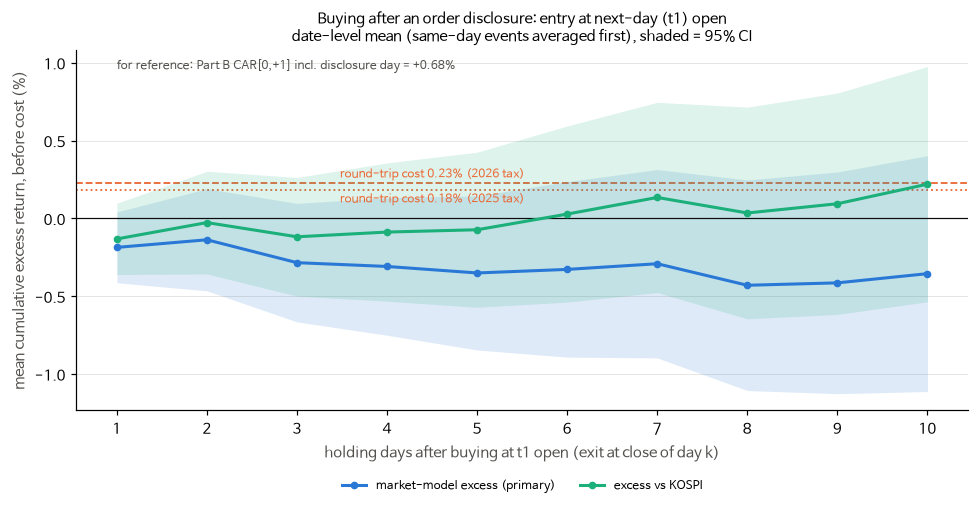

In [13]:
# ---- 2-4. 그림: t1 시가 진입 후 1~10일 평균 누적 초과수익 (날짜 단위, 95% CI) ----
BLUE, ORANGE, AQUA, INK, INK2, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e", "#e4e3df"
def date_path(col, sub=lambda x: x):
    mu, lo, hi = [], [], []
    for h in HS:
        x = sub(HOLD[HOLD["h"] == h]); dl = x[col].groupby(x["tdate"]).mean()
        se = dl.std(ddof=1) / np.sqrt(len(dl)); m = dl.mean()
        mu.append(m * 100); lo.append((m - 1.96 * se) * 100); hi.append((m + 1.96 * se) * 100)
    return np.array(mu), np.array(lo), np.array(hi)
fig, ax = plt.subplots(figsize=(9, 4.8))
for col, colr, lab in [("시장모형 초과", BLUE, "market-model excess (primary)"), ("KOSPI 초과", AQUA, "excess vs KOSPI")]:
    mu, lo, hi = date_path(col)
    ax.plot(HS, mu, color=colr, lw=2, marker="o", ms=4, label=lab, zorder=3)
    ax.fill_between(HS, lo, hi, color=colr, alpha=0.15, lw=0, zorder=2)
for c, ls, lab, va in [(0.18, ":", "round-trip cost 0.18% (2025 tax)", "top"), (0.23, "--", "round-trip cost 0.23% (2026 tax)", "bottom")]:
    ax.axhline(c, color=ORANGE, lw=1.2, ls=ls, zorder=1)
    ax.text(4.5, c + (0.01 if va == "bottom" else -0.01), lab, color=ORANGE, fontsize=8, va=va, ha="center")
ax.axhline(0, color=INK, lw=0.8)
pb = evB["ann_rep"].mean() * 100
ax.text(1, ax.get_ylim()[1] * 0.95, f"for reference: Part B CAR[0,+1] incl. disclosure day = +{pb:.2f}%", color=INK2, fontsize=8, va="top")
ax.set_xticks(HS); ax.set_xlabel("holding days after buying at t1 open (exit at close of day k)", color=INK2)
ax.set_ylabel("mean cumulative excess return, before cost (%)", color=INK2)
ax.set_title("Buying after an order disclosure: entry at next-day (t1) open\n"
             "date-level mean (same-day events averaged first), shaded = 95% CI", fontsize=10)
ax.legend(fontsize=8, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
ax.grid(axis="y", color=GRID, lw=0.6, zorder=0); ax.set_axisbelow(True)
for s_ in ["top", "right"]: ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_ext2_disclosure.png", bbox_inches="tight"); plt.show()

In [14]:
# ---- 2-5. 검정 수와 다중검정 기준 ----
pcols = ["이벤트 p", "Wilcoxon p", "날짜 p"]
P2 = T2.melt(id_vars=["표본", "보유", "수익률", "비용"], value_vars=pcols, var_name="검정", value_name="p").dropna(subset=["p"])
NT2 = len(P2)
P2.to_csv(f"{RES_DIR}/T2_3_test_count.csv", index=False, encoding="utf-8-sig")
print(f"작업 2 보고 검정 수: {NT2}개 (표본 4 × 보유 3 × 수익률 3 × 비용 3 × 검정 3) → Bonferroni 기준 p < {0.05/NT2:.6f}")
print(f"사전 지정 판정 검정 1개 (전체 · 5일 · 시장모형 초과 · 0.23% · 날짜 t): t = {J['날짜 t']:.2f}, p = {J['날짜 p']:.4f} (단독 기준 t > 1.96)")
sig = P2[P2["p"] < 0.05 / NT2]
print(f"Bonferroni 통과: {len(sig)}개"); display(sig)

작업 2 보고 검정 수: 324개 (표본 4 × 보유 3 × 수익률 3 × 비용 3 × 검정 3) → Bonferroni 기준 p < 0.000154
사전 지정 판정 검정 1개 (전체 · 5일 · 시장모형 초과 · 0.23% · 날짜 t): t = -2.30, p = 0.0221 (단독 기준 t > 1.96)
Bonferroni 통과: 12개


,표본,보유,수익률,비용,검정,p
8,전체,1일,시장모형 초과,비용 0.23% (2026),이벤트 p,0.0001
109,전체,1일,원 수익률,비용 0.18% (2025),Wilcoxon p,0.0000
110,전체,1일,원 수익률,비용 0.23% (2026),Wilcoxon p,0.0000
112,전체,1일,KOSPI 초과,비용 0.18% (2025),Wilcoxon p,0.0000
113,전체,1일,KOSPI 초과,비용 0.23% (2026),Wilcoxon p,0.0000
115,전체,1일,시장모형 초과,비용 0.18% (2025),Wilcoxon p,0.0000
116,전체,1일,시장모형 초과,비용 0.23% (2026),Wilcoxon p,0.0000
190,후반 (t0 2020-12-31 이후),1일,원 수익률,비용 0.18% (2025),Wilcoxon p,0.0001
191,후반 (t0 2020-12-31 이후),1일,원 수익률,비용 0.23% (2026),Wilcoxon p,0.0000
194,후반 (t0 2020-12-31 이후),1일,KOSPI 초과,비용 0.23% (2026),Wilcoxon p,0.0001


---
## 작업 3. 같은 가설을 다른 신호로, 아직 보지 않은 과거 기간(2004~2014)에 검증
"같은 신호의 표본 외 검증"이 아니라, **같은 가설**(미국 조선 고객의 밤사이 정보가 다음 날 한국 조선 장중에 반영된다)을 과거에도 경제적 의미가 같은 신호로 검증함. Cheniere(LNG)는 2016년 이전엔 LNG 수입 터미널 회사라 쓰지 않음.

- **단계 A**: 설정을 `results/ext2/config_ext2_hist.json`에 저장하고 저장 시각·해시를 기록함 (한국 수익률을 보기 전). 파일이 이미 있으면 덮어쓰지 않고, 코드의 설정과 같은지만 확인함.
- **단계 B**: 데이터 가용성만 확인함. **한국 종목의 수익률·회귀는 계산하지도 출력하지도 않음.**
- 단계 C(실행)는 별도 요청 시 진행.

In [15]:
# ---- 3-A. 설정 고정 → config_ext2_hist.json ----
import json, hashlib
from datetime import datetime
from zoneinfo import ZoneInfo
CFG_PATH = os.path.join(RES_DIR, "config_ext2_hist.json")
CFG = {
    "task": "ext2 작업 3 — 같은 가설, 다른 신호, 과거 기간(2004~2014)",
    "hypothesis": "미국 조선 고객(LNG·해운 선주)의 밤사이 정보가 다음 날 한국 조선 장중 수익에 반영된다",
    "period": {"start": "2004-01-02", "end": "2014-12-31",
               "download_start": "2004-01-01", "download_end_exclusive": "2015-01-01",
               "note": "기존 표본(2015-01~2026-09)과 겹치지 않음"},
    "us_signal": {"candidates": {"GLNG": "Golar LNG", "TK": "Teekay"},
                  "inclusion_rule": "yfinance 데이터가 2004-06-30 이전부터 있는 종목만 포함. 둘 다 없으면 작업 중단",
                  "definition": "포함 종목 로그수익률의 평균(us_ship) − S&P500(^GSPC), 한국 시가 전 공개분 (Part F align_us_to_kr 그대로)",
                  "yfinance_auto_adjust": True,
                  "excluded": {"LNG": "Cheniere는 2016년 이전엔 LNG 수입 터미널 회사라 과거 신호로 쓰지 않음"}},
    "us_control": {"^GSPC": "S&P 500"},
    "oil_control": {"main": {"ticker": "CL=F", "name": "WTI", "reason": "BZ=F는 2007-07 이전 데이터 없음"},
                    "aux": {"ticker": "BZ=F", "name": "Brent", "from": "2007-07-01",
                            "note": "2007-07 이후 구간에서 원래 식(브렌트)과 똑같이 한 번 더 (보조)"}},
    "kr_basket": {"009540": "현대중공업 (당시 조선 사업 직접 영위, 2017 인적분할 전)", "010620": "현대미포조선",
                  "010140": "삼성중공업", "042660": "대우조선해양"},
    "kr_source": "pykrx 네이버 수정주가 (Part F load_ohlc 그대로), 동일가중 바스켓 − KOSPI",
    "kospi_source": "FinanceDataReader KS11 (Open, Close)",
    "kr_returns_filter": "Part F kr_returns 그대로 (거래량 0·시가 ≤ 0 제외, |수익률| > 30.5% NaN)",
    "regressions": {"targets": ["ship_gap_ex", "ship_intra_ex", "ship_cc_ex"],
                    "regressors": ["us_ship", "spx", "oil (main: CL=F / aux: BZ=F)"],
                    "estimator": "OLS, HAC(Newey-West) maxlags = 5 (Part F hac_ols 그대로)"},
    "primary_test": {"single": True,
                     "rule": "F2: ship_intra_ex ~ us_ship + spx + oil(CL=F) 에서 us_ship 계수 > 0 이고 HAC t > 1.96 이면 지지",
                     "auxiliary": ["F1 시가 갭(ship_gap_ex)", "종가(ship_cc_ex)", "분위표", "F3 전략 성과", "BZ=F 보조 회귀(2007-07~)"]},
    "quintiles": "signal 전체 표본 5분위(pd.qcut), 분위별 ship_gap_ex·ship_intra_ex 평균 (Part F와 같음, 기술통계)",
    "strategy": {"rank": "signal의 확장 백분위, min_periods = 250 (2004~2014 표본 안에서만)",
                 "entry": "백분위 ≥ 0.8 (상위 20%)인 날 시가 매수 → 같은 날 종가 매도", "asset": "조선 바스켓 동일가중 장중 수익률"},
    "costs": {"commission_each_side": 0.00015, "sell_tax": 0.0030,
              "sell_tax_note": "당시 코스피 매도세 0.30% = 증권거래세 0.15% + 농특세 0.15%",
              "round_trip": 0.00015 * 2 + 0.0030},
    "compare_with": ["results_cross/F1_regression.csv", "results_cross/F2_quintiles.csv", "results_cross/F3_strategy.csv"],
    "allowed_code_changes": "티커·기간·유가 변수만. 회귀식·HAC lag 5·전략 규칙·함수 로직은 Part F와 동일",
    "korean_returns_viewed_before_saving": False,
}
def _cfg_hash(c):
    body = {k: v for k, v in c.items() if k not in ("saved_at", "sha256")}
    return hashlib.sha256(json.dumps(body, ensure_ascii=False, sort_keys=True).encode("utf-8")).hexdigest()
if os.path.exists(CFG_PATH):
    with open(CFG_PATH, encoding="utf-8") as f:
        saved = json.load(f)
    assert saved["sha256"] == _cfg_hash(saved) == _cfg_hash(CFG), "저장된 설정과 코드의 설정이 다름 — 진행하지 않음"
    print(f"기존 설정 파일 사용 (덮어쓰지 않음): 저장 시각 {saved['saved_at']}, sha256 {saved['sha256'][:16]}…")
    CFG = saved
else:
    CFG["saved_at"] = datetime.now(ZoneInfo("Asia/Seoul")).isoformat(timespec="seconds")
    CFG["sha256"] = _cfg_hash(CFG)
    with open(CFG_PATH, "w", encoding="utf-8") as f:
        json.dump(CFG, f, ensure_ascii=False, indent=2)
    print(f"설정 저장: {CFG_PATH}, 저장 시각 {CFG['saved_at']}, sha256 {CFG['sha256'][:16]}…")

기존 설정 파일 사용 (덮어쓰지 않음): 저장 시각 2026-09-30T22:03:06+09:00, sha256 54c172598dc2876d…


In [16]:
# ---- 3-B. 데이터 가용성만 (한국 종목 수익률·회귀는 계산·출력하지 않음) ----
from pykrx import stock
H_START, H_END = CFG["period"]["start"], CFG["period"]["end"]
H_DL0, H_DL1 = CFG["period"]["download_start"], CFG["period"]["download_end_exclusive"]

# (1) KOSPI 커버리지 (FDR KS11)
kx3 = fdr.DataReader("KS11", H_DL0, H_DL1).loc[H_START:H_END]
CAL3 = kx3.index
bday = pd.bdate_range(H_START, H_END)
T3_K = pd.DataFrame([{"지수": "KOSPI (FDR KS11)", "첫날": CAL3.min().date(), "마지막날": CAL3.max().date(), "거래일": len(CAL3),
                      "평일 중 없는 날(휴장 포함)": len(bday.difference(CAL3)),
                      "연도별 거래일 최소/최대": f"{kx3.groupby(kx3.index.year).size().min()} / {kx3.groupby(kx3.index.year).size().max()}",
                      "시가 결측·0 이하": int(((kx3['Open'].isna()) | (kx3['Open'] <= 0)).sum()),
                      "시가가 고가·저가 범위 밖": int(((kx3['Open'] < kx3['Low']) | (kx3['Open'] > kx3['High'])).sum()),
                      "시가=고가=저가=종가": int(((kx3['Open'] == kx3['High']) & (kx3['High'] == kx3['Low']) & (kx3['Low'] == kx3['Close'])).sum())}])
T3_K.to_csv(f"{RES_DIR}/T3_B1_kospi_coverage.csv", index=False, encoding="utf-8-sig"); display(T3_K)
print("KOSPI 연도별 거래일:", kx3.groupby(kx3.index.year).size().to_dict())

# (2) 미국: GLNG·TK 시작일·결측 + 통제변수
us3_t = list(CFG["us_signal"]["candidates"]) + list(CFG["us_control"]) + [CFG["oil_control"]["main"]["ticker"], CFG["oil_control"]["aux"]["ticker"]]
US3 = {}
for t in us3_t:
    s = None
    for _ in range(3):
        s = yf.download(t, start="1990-01-01", end=H_DL1, auto_adjust=True, progress=False)["Close"]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        if s.notna().sum() > 0: break
        time.sleep(2)
    s.index = pd.to_datetime(s.index).tz_localize(None); US3[t] = s.dropna()
spx_days = US3["^GSPC"].loc[H_START:H_END].index
rows = []
for t in us3_t:
    s = US3[t]; sp = s.loc[H_START:H_END]
    ref = spx_days if not t.endswith("=F") else sp.index        # 선물은 거래 달력이 달라 S&P500 대비 결측은 보지 않음
    stale = (sp.diff() == 0).astype(int); run = stale.groupby((stale == 0).cumsum()).sum().max() if len(sp) else np.nan
    lr = np.log(sp).diff()
    rows.append({"티커": t, "이름": {**CFG["us_signal"]["candidates"], "^GSPC": "S&P 500", "CL=F": "WTI", "BZ=F": "Brent"}[t],
                 "yfinance 첫날(전체 이력)": s.index.min().date() if len(s) else None,
                 "기간 내 첫날": sp.index.min().date() if len(sp) else None, "기간 내 마지막날": sp.index.max().date() if len(sp) else None,
                 "기간 내 거래일": len(sp),
                 "S&P500 거래일 대비 결측": (len(spx_days.difference(sp.index)) if not t.endswith("=F") else np.nan),
                 "종가 동일 연속 최대(일)": int(run) if pd.notna(run) else np.nan,
                 "최대 |일간 로그수익률|": float(lr.abs().max()), "최대일": lr.abs().idxmax().date() if len(sp) > 1 else None,
                 "포함 규칙(2004-06-30 이전 시작)": (s.index.min() <= pd.Timestamp("2004-06-30")) if t in CFG["us_signal"]["candidates"] else "통제변수"})
T3_US = pd.DataFrame(rows).set_index("티커")
T3_US.to_csv(f"{RES_DIR}/T3_B2_us_coverage.csv", encoding="utf-8-sig"); display(T3_US)
SIG3 = [t for t in CFG["us_signal"]["candidates"] if T3_US.loc[t, "포함 규칙(2004-06-30 이전 시작)"] is True]
print("신호 포함 종목:", SIG3)
assert SIG3, "GLNG·TK 모두 포함 규칙을 만족하지 않음 — 작업 중단"

# (3) 한국 4종목: 데이터 범위, 거래정지(거래량 0 또는 행 없음) 구간, 시가 품질 — 가격·거래량 존재 여부만 봄
KR3 = CFG["kr_basket"]
rows, halts = [], []
for c, nm in KR3.items():
    df = stock.get_market_ohlcv(H_START.replace("-", ""), H_END.replace("-", ""), c)
    df.index = pd.to_datetime(df.index)
    df = df.rename(columns={"시가": "open", "고가": "high", "저가": "low", "종가": "close", "거래량": "vol"}).reindex(CAL3)
    no_row = df["close"].isna(); halt = no_row | (df["vol"] == 0)
    trd = ~halt
    grp = (halt != halt.shift()).cumsum()
    for _, g in df[halt].groupby(grp[halt]):
        halts.append({"종목": nm, "code": c, "시작": g.index.min().date(), "끝": g.index.max().date(), "거래일 수": len(g),
                      "사유 구분": "행 없음" if no_row[g.index].all() else ("거래량 0" if (~no_row[g.index]).all() else "행 없음+거래량 0")})
    t_ = df[trd]
    rows.append({"code": c, "종목(당시)": nm, "첫 데이터": df["close"].first_valid_index().date() if df["close"].notna().any() else None,
                 "마지막 데이터": df["close"].last_valid_index().date() if df["close"].notna().any() else None,
                 "KOSPI 거래일": len(CAL3), "행 없음": int(no_row.sum()), "거래량 0": int((df["vol"] == 0).sum()),
                 "거래 가능일": int(trd.sum()), "정지 구간 수": int((grp[halt]).nunique()),
                 "최장 정지(거래일)": int(pd.Series([h["거래일 수"] for h in halts if h["code"] == c] or [0]).max()),
                 "시가 결측·0 이하(거래일)": int(((t_["open"].isna()) | (t_["open"] <= 0)).sum()),
                 "시가가 고가·저가 범위 밖(거래일)": int(((t_["open"] < t_["low"]) | (t_["open"] > t_["high"])).sum()),
                 "시가=고가=저가=종가(거래일)": int(((t_["open"] == t_["high"]) & (t_["high"] == t_["low"]) & (t_["low"] == t_["close"])).sum())})
    time.sleep(0.3)
T3_KR = pd.DataFrame(rows).set_index("code"); T3_H = pd.DataFrame(halts)
T3_KR.to_csv(f"{RES_DIR}/T3_B3_kr_coverage.csv", encoding="utf-8-sig")
T3_H.to_csv(f"{RES_DIR}/T3_B4_kr_halts.csv", index=False, encoding="utf-8-sig")
display(T3_KR)
print(f"거래정지 구간 {len(T3_H)}개" + (" (5거래일 이상만 표시):" if len(T3_H) else ""))
if len(T3_H): display(T3_H[T3_H["거래일 수"] >= 5]); print("1~4거래일 구간 수:", T3_H[T3_H["거래일 수"] < 5].groupby("종목").size().to_dict())

# (4) 신호 가용성 (미국 데이터만 사용): 한국 거래일 중 시가 전 미국 신호가 있는 날
us3_ret = pd.DataFrame({t: np.log(US3[t].loc[H_DL0:H_END]).diff() for t in us3_t})
usk3 = align_us_to_kr(us3_ret, CAL3)
sig3 = usk3[SIG3].mean(axis=1, skipna=True) - usk3["^GSPC"]
rk3 = sig3.expanding(min_periods=250).rank(pct=True)          # 설정의 min_periods = 250
T3_S = pd.DataFrame([{"항목": "한국 거래일", "값": len(CAL3)},
                     {"항목": "신호(포함 종목 평균 − S&P500) 있는 날", "값": int(sig3.notna().sum())},
                     *[{"항목": f"{t} 수익률 있는 날", "값": int(usk3[t].notna().sum())} for t in SIG3],
                     {"항목": "CL=F(WTI) 있는 날", "값": int(usk3["CL=F"].notna().sum())},
                     {"항목": "BZ=F(Brent) 있는 날 (2007-07-01 이후 한국 거래일 중)", "값": f"{int(usk3['BZ=F'].loc['2007-07-01':].notna().sum())} / {len(CAL3[CAL3 >= '2007-07-01'])}"},
                     {"항목": "전략 백분위(최소 250일) 첫 판정일", "값": str(rk3.first_valid_index().date())},
                     {"항목": "전략 판정 가능일 수", "값": int(rk3.notna().sum())}])
T3_S.to_csv(f"{RES_DIR}/T3_B5_signal_coverage.csv", index=False, encoding="utf-8-sig"); display(T3_S.set_index("항목"))
print("※ 단계 B: 한국 종목의 수익률·회귀는 계산하지 않았음. 단계 C는 별도 요청 시 실행.")

,지수,첫날,마지막날,거래일,평일 중 없는 날(휴장 포함),연도별 거래일 최소/최대,시가 결측·0 이하,시가가 고가·저가 범위 밖,시가=고가=저가=종가
0,KOSPI (FDR KS11),2004-01-02,2014-12-30,2731,138,245 / 253,0,0,0


KOSPI 연도별 거래일: {2004: 249, 2005: 249, 2006: 247, 2007: 246, 2008: 248, 2009: 253, 2010: 251, 2011: 248, 2012: 248, 2013: 247, 2014: 245}


,이름,yfinance 첫날(전체 이력),기간 내 첫날,기간 내 마지막날,기간 내 거래일,S&P500 거래일 대비 결측,종가 동일 연속 최대(일),최대 |일간 로그수익률|,최대일,포함 규칙(2004-06-30 이전 시작)
티커,,,,,,,,,,
GLNG,Golar LNG,2003-07-15,2004-01-02,2014-12-31,2769,0.0000,1,0.2364,2009-03-02,True
TK,Teekay,1995-07-20,2004-01-02,2014-12-31,2769,0.0000,1,0.2002,2008-11-06,True
^GSPC,S&P 500,1990-01-02,2004-01-02,2014-12-31,2769,0.0000,1,0.1096,2008-10-13,통제변수
CL=F,WTI,2000-08-23,2004-01-05,2014-12-31,2765,NaN,1,0.1641,2008-12-22,통제변수
BZ=F,Brent,2007-07-30,2007-07-30,2014-12-31,1818,NaN,3,0.1271,2008-12-31,통제변수


신호 포함 종목: ['GLNG', 'TK']


,종목(당시),첫 데이터,마지막 데이터,KOSPI 거래일,행 없음,거래량 0,거래 가능일,정지 구간 수,최장 정지(거래일),시가 결측·0 이하(거래일),시가가 고가·저가 범위 밖(거래일),시가=고가=저가=종가(거래일)
code,,,,,,,,,,,,
009540,"현대중공업 (당시 조선 사업 직접 영위, 2017 인적분할 전)",2014-07-09,2014-12-30,2731,2613,0,118,1,2613,0,0,0
010620,현대미포조선,2013-09-25,2014-12-30,2731,2420,0,311,1,2420,0,0,0
010140,삼성중공업,2014-07-09,2014-12-30,2731,2613,0,118,1,2613,0,0,0
042660,대우조선해양,2014-07-09,2014-12-30,2731,2613,0,118,1,2613,0,0,0


거래정지 구간 4개 (5거래일 이상만 표시):


,종목,code,시작,끝,거래일 수,사유 구분
0,"현대중공업 (당시 조선 사업 직접 영위, 2017 인적분할 전)",009540,2004-01-02,2014-07-08,2613,행 없음
1,현대미포조선,010620,2004-01-02,2013-09-24,2420,행 없음
2,삼성중공업,010140,2004-01-02,2014-07-08,2613,행 없음
3,대우조선해양,042660,2004-01-02,2014-07-08,2613,행 없음


1~4거래일 구간 수: {}


,값
항목,
한국 거래일,2731
신호(포함 종목 평균 − S&P500) 있는 날,2645
GLNG 수익률 있는 날,2645
TK 수익률 있는 날,2645
CL=F(WTI) 있는 날,2642
BZ=F(Brent) 있는 날 (2007-07-01 이후 한국 거래일 중),1738 / 1862
전략 백분위(최소 250일) 첫 판정일,2005-01-19
전략 판정 가능일 수,2396


※ 단계 B: 한국 종목의 수익률·회귀는 계산하지 않았음. 단계 C는 별도 요청 시 실행.


### 3-B 추가: pykrx가 과거 구간을 주지 않는 문제 — 같은 네이버 수정주가의 다른 경로 (참고, 아직 채택 안 함)
pykrx의 네이버 경로는 최근 약 3,000거래일만 돌려줘서 2004~2014 대부분이 비어 있음. 같은 네이버 차트 원천의 `api.finance.naver.com/siseJson.naver`(기간 지정)로 **커버리지만** 확인함. 수익률·회귀는 계산하지 않음. 이 경로를 단계 C에 쓸지는 설정 변경이므로 사용자 결정 후 별도 기록.

In [17]:
# ---- 3-B 추가. 네이버 siseJson 경로 커버리지 (가격·거래량 존재 여부와 pykrx 겹침 구간 일치만) ----
import ast
def naver_sisejson(code, start, end):
    r = requests.get("https://api.finance.naver.com/siseJson.naver",
                     params={"symbol": code, "requestType": 1, "startTime": start.replace("-", ""), "endTime": end.replace("-", ""),
                             "timeframe": "day"}, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
    rows = ast.literal_eval(r.text.strip())
    df = pd.DataFrame(rows[1:], columns=[x.strip() for x in rows[0]])
    df.index = pd.to_datetime(df["날짜"].astype(str))
    return df.rename(columns={"시가": "open", "고가": "high", "저가": "low", "종가": "close", "거래량": "vol"})[["open", "high", "low", "close", "vol"]].astype(float)
import requests
rows, halts = [], []
for c, nm in KR3.items():
    df = naver_sisejson(c, H_START, H_END).reindex(CAL3)
    pk = stock.get_market_ohlcv("20130101", H_END.replace("-", ""), c); pk.index = pd.to_datetime(pk.index)
    j = df.join(pk[["시가", "고가", "저가", "종가"]], how="inner").dropna()
    same = float(((j["open"] == j["시가"]) & (j["high"] == j["고가"]) & (j["low"] == j["저가"]) & (j["close"] == j["종가"])).mean()) if len(j) else np.nan
    no_row = df["close"].isna(); halt = no_row | (df["vol"] == 0); grp = (halt != halt.shift()).cumsum()
    for _, g in df[halt].groupby(grp[halt]):
        halts.append({"종목": nm, "code": c, "시작": g.index.min().date(), "끝": g.index.max().date(), "거래일 수": len(g),
                      "사유 구분": "행 없음" if no_row[g.index].all() else ("거래량 0" if (~no_row[g.index]).all() else "행 없음+거래량 0")})
    t_ = df[~halt]
    rows.append({"code": c, "종목(당시)": nm, "첫 데이터": df["close"].first_valid_index().date(), "마지막 데이터": df["close"].last_valid_index().date(),
                 "KOSPI 거래일": len(CAL3), "행 없음": int(no_row.sum()), "거래량 0": int((df["vol"] == 0).sum()), "거래 가능일": int((~halt).sum()),
                 "정지 구간 수": int(grp[halt].nunique()),
                 "최장 정지(거래일)": int(max([h["거래일 수"] for h in halts if h["code"] == c] or [0])),
                 "시가 결측·0 이하(거래일)": int(((t_["open"].isna()) | (t_["open"] <= 0)).sum()),
                 "시가가 고가·저가 범위 밖(거래일)": int(((t_["open"] < t_["low"]) | (t_["open"] > t_["high"])).sum()),
                 "시가=고가=저가=종가(거래일)": int(((t_["open"] == t_["high"]) & (t_["high"] == t_["low"]) & (t_["low"] == t_["close"])).sum()),
                 "pykrx와 겹치는 날": len(j), "겹치는 날 OHLC 완전 일치 비율": same})
    time.sleep(0.5)
T3_KR2 = pd.DataFrame(rows).set_index("code"); T3_H2 = pd.DataFrame(halts, columns=["종목", "code", "시작", "끝", "거래일 수", "사유 구분"])
T3_KR2.to_csv(f"{RES_DIR}/T3_B6_kr_coverage_naver_sisejson.csv", encoding="utf-8-sig")
T3_H2.to_csv(f"{RES_DIR}/T3_B7_kr_halts_naver_sisejson.csv", index=False, encoding="utf-8-sig")
display(T3_KR2)
print(f"거래정지(거래량 0 또는 행 없음) 구간 {len(T3_H2)}개:"); display(T3_H2)
print("※ 커버리지와 겹침 구간 가격 일치만 확인함. 한국 종목 수익률·회귀는 계산하지 않았음.")

,종목(당시),첫 데이터,마지막 데이터,KOSPI 거래일,행 없음,거래량 0,거래 가능일,정지 구간 수,최장 정지(거래일),시가 결측·0 이하(거래일),시가가 고가·저가 범위 밖(거래일),시가=고가=저가=종가(거래일),pykrx와 겹치는 날,겹치는 날 OHLC 완전 일치 비율
code,,,,,,,,,,,,,,
009540,"현대중공업 (당시 조선 사업 직접 영위, 2017 인적분할 전)",2004-01-02,2014-12-30,2731,0,0,2731,0,0,0,0,0,118,1.0000
010620,현대미포조선,2004-01-02,2014-12-30,2731,0,0,2731,0,0,0,0,0,311,1.0000
010140,삼성중공업,2004-01-02,2014-12-30,2731,0,0,2731,0,0,0,0,0,118,1.0000
042660,대우조선해양,2004-01-02,2014-12-30,2731,0,0,2731,0,0,0,0,1,118,1.0000


거래정지(거래량 0 또는 행 없음) 구간 0개:


,종목,code,시작,끝,거래일 수,사유 구분


※ 커버리지와 겹침 구간 가격 일치만 확인함. 한국 종목 수익률·회귀는 계산하지 않았음.


### 3-A′. 설정 변경 기록 (사용자 승인)
한국 주가 경로를 pykrx → 네이버 siseJson으로 바꿈. 원 설정 파일은 그대로 두고 `config_ext2_hist_amendment.json`에 변경 내용·사유·시각을 기록함 (한국 수익률 확인 전). 이미 있으면 덮어쓰지 않고 해시만 확인함.

In [18]:
# ---- 3-A′. 설정 변경 기록 ----
AMD_PATH = os.path.join(RES_DIR, "config_ext2_hist_amendment.json")
AMD = {
    "amends": "config_ext2_hist.json",
    "original_saved_at": CFG["saved_at"], "original_sha256": CFG["sha256"],
    "change": {"field": "kr_source",
               "from": CFG["kr_source"],
               "to": "네이버 siseJson (api.finance.naver.com/siseJson.naver, requestType=1, timeframe=day, 기간 지정). "
                     "Part F load_ohlc의 가격 조회 부분만 교체하고, 반환 형식(Open, Close, Volume)과 이후 로직(load_panel, kr_returns, basket 등)은 동일"},
    "reason": ["같은 네이버 수정주가 원천",
               "pykrx와 겹치는 구간(118~311일) OHLC 100% 일치",
               "pykrx 네이버 경로는 최근 약 3,000거래일만 반환해 2004~2014 대부분이 비어 있음",
               "한국 수익률 확인 전 결정"],
    "approved_by": "사용자 승인 (2026-09-30 대화)",
    "pre_committed_checks_before_stage_C": [
        "1. 2004~2014 권리 이벤트(증자·분할 등) 전후 siseJson 수정주가 vs 무조정 Yahoo(보조: 네이버 수정 전 시세) 수익률 비교",
        "2. F 확장 Step 1과 같은 시가 점검: 저가 ≤ 시가 ≤ 고가 위반 수, 시가·종가 수정 비율 일치 여부",
        "3. 시가=고가=저가=종가(제한폭 고정 추정)인 날 종목·연도별 일수. 거래량 0이 아니면 그대로 둠"],
    "checks_do_not_change_config": True,
    "pre_committed_auxiliary": "점검 1의 가격 수정 이벤트·DART 자본변동 이벤트 ±1일과 점검 2의 시가·종가 수정 비율 불일치 종목·일을 뺀 F2 재추정 (보조, 판정에 쓰지 않음)",
    "korean_returns_viewed_before_saving": False,
}
if os.path.exists(AMD_PATH):
    with open(AMD_PATH, encoding="utf-8") as f:
        saved = json.load(f)
    assert saved["sha256"] == _cfg_hash(saved) == _cfg_hash(AMD), "저장된 변경 기록과 코드가 다름 — 진행하지 않음"
    AMD = saved; print(f"기존 변경 기록 사용 (덮어쓰지 않음): 저장 시각 {AMD['saved_at']}, sha256 {AMD['sha256'][:16]}…")
else:
    AMD["saved_at"] = datetime.now(ZoneInfo("Asia/Seoul")).isoformat(timespec="seconds")
    AMD["sha256"] = _cfg_hash(AMD)
    with open(AMD_PATH, "w", encoding="utf-8") as f:
        json.dump(AMD, f, ensure_ascii=False, indent=2)
    print(f"변경 기록 저장: {AMD_PATH}, 저장 시각 {AMD['saved_at']}, sha256 {AMD['sha256'][:16]}…")

기존 변경 기록 사용 (덮어쓰지 않음): 저장 시각 2026-09-30T23:24:30+09:00, sha256 1b011d264e251b65…


### 3-P. 단계 C 전 점검 (결과로 설정을 바꾸지 않음)
- **점검 1** 권리 이벤트: siseJson 수정주가 ÷ 무조정 가격 = 수정 비율. 비율이 바뀐 날(= 가격 수정이 적용된 날), DART 자본변동 공시, 무조정 가격의 |일간 수익률| > 15.5%(2015-06 이전 제한폭 ±15% 밖 → 권리락 등)인 날을 모아 수정/무조정 수익률을 나란히 봄.
  - 무조정 가격: Yahoo `auto_adjust=False`의 Close(액면분할만 반영, 증자·배당 미반영), 보조로 네이버 수정 전 시세(모바일 API).
  - 판정: 수정주가 수익률이 ±15.5% 안이면 "수정 반영됨", 밖이면 "수정 누락 의심".
- **점검 2** 시가: 저가 ≤ 시가 ≤ 고가 위반, 같은 날 시가·종가 수정 비율 일치 (허용 오차 1/수정시가 + 1/수정종가, F 확장과 같음).
- **점검 3** 시가=고가=저가=종가인 날 (종목 × 연도, 거래량 > 0 / = 0 구분).

In [19]:
# ---- 3-P0. 점검용 데이터: siseJson 수정 OHLC, Yahoo 무조정, 네이버 수정 전 ----
HDR = {"User-Agent": "Mozilla/5.0"}
def naver_raw_daily(code, start, page_size=60, max_pages=400):   # F 확장 Step 1과 같은 함수
    rows = []
    for page in range(1, max_pages + 1):
        r = requests.get(f"https://m.stock.naver.com/api/stock/{code}/price",
                         params={"pageSize": page_size, "page": page}, headers=HDR, timeout=20)
        js = r.json()
        if not isinstance(js, list) or not js: break
        rows += js
        if js[-1]["localTradedAt"] < start: break
        time.sleep(0.12)
    if not rows: return None
    df = pd.DataFrame(rows); df["date"] = pd.to_datetime(df["localTradedAt"])
    for k in ["open", "high", "low", "close"]:
        df[k] = df[f"{k}Price"].astype(str).str.replace(",", "").astype(float)
    df["vol"] = df["accumulatedTradingVolume"].astype(float)
    return df.set_index("date").sort_index().loc[start:, ["open", "high", "low", "close", "vol"]]

ADJH, YRAW, NRAW = {}, {}, {}
for c in KR3:
    ADJH[c] = naver_sisejson(c, H_START, H_END).reindex(CAL3)
    try:
        y = yf.download(f"{c}.KS", start=H_DL0, end=H_DL1, auto_adjust=False, progress=False)
        if isinstance(y.columns, pd.MultiIndex): y.columns = y.columns.get_level_values(0)
        y.index = pd.to_datetime(y.index).tz_localize(None)
        YRAW[c] = y.rename(columns={"Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "vol"})[
            ["open", "high", "low", "close", "vol"]].reindex(CAL3) if len(y) else None
    except Exception as ex:
        print(f"Yahoo 실패({c}): {ex}"); YRAW[c] = None
    nr = naver_raw_daily(c, H_START)
    NRAW[c] = nr.loc[:H_END].reindex(CAL3) if nr is not None else None
    time.sleep(0.5)
T3P0 = pd.DataFrame([{"code": c, "종목": KR3[c],
                      "Yahoo 무조정 거래일(거래량>0)": int((YRAW[c]["vol"] > 0).sum()) if YRAW[c] is not None else 0,
                      "네이버 수정 전 거래일(거래량>0)": int((NRAW[c]["vol"] > 0).sum()) if NRAW[c] is not None else 0} for c in KR3]).set_index("code")
display(T3P0)

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 010620.KS"}}}


$010620.KS: possibly delisted; no timezone found



1 Failed download:


['010620.KS']: possibly delisted; no timezone found


,종목,Yahoo 무조정 거래일(거래량>0),네이버 수정 전 거래일(거래량>0)
code,,,
009540,"현대중공업 (당시 조선 사업 직접 영위, 2017 인적분할 전)",2730,2731
010620,현대미포조선,0,0
010140,삼성중공업,2730,2731
042660,대우조선해양,2730,2731


In [20]:
# ---- 3-P1. 점검 1: 권리 이벤트 전후 수정 vs 무조정 수익률 ----
import OpenDartReader
DART_API_KEY = os.environ.get("DART_API_KEY", "")
assert DART_API_KEY.strip(), "환경변수 DART_API_KEY가 비어 있습니다 — 진행하지 않음"
_redact = lambda s: str(s).replace(DART_API_KEY, "***")
dart = OpenDartReader(DART_API_KEY)
CAP_PAT = r"감자|유상증자|무상증자|주식분할|주식병합|분할|합병|신주|권리락|매매거래정지|거래재개|상장폐지"
CAP_EXCL = r"정정|첨부|자회사|종속회사|\[기재|대량보유|소유상황|투자설명서|증권발행실적|일괄신고|결과|조회공시|해명"
def _kdate(x):
    m = re.match(r"(\d{4})\D+(\d{1,2})\D+(\d{1,2})", str(x))
    return pd.Timestamp(int(m.group(1)), int(m.group(2)), int(m.group(3))) if m else None
import re
DLH, DEV = {}, []
for c in KR3:
    try:
        df = dart.list(c, start=H_START, end=H_END, kind="", final=False); df["date"] = pd.to_datetime(df["rcept_dt"])
    except Exception as ex:
        print(f"DART list 실패({c}): {_redact(ex)}"); df = pd.DataFrame(columns=["date", "report_nm"])
    DLH[c] = df
    for ev in ["무상증자", "유상증자"]:
        try:
            x = dart.event(c, ev, start=H_START, end=H_END)
        except Exception as ex:
            print(f"DART event 실패({c},{ev}): {_redact(ex)}"); x = None
        if x is None or len(x) == 0: continue
        for _, e in x.iterrows():
            rd = _kdate(e.get("nstk_asstd"))
            if rd is None or rd < pd.Timestamp(H_START) or rd > pd.Timestamp(H_END): continue
            i = CAL3.searchsorted(rd) - 1
            DEV.append({"code": c, "공시": ev, "신주배정기준일": rd.date(), "권리락일(추정)": CAL3[i]})
        time.sleep(0.3)
    time.sleep(0.3)
capH = pd.concat([DLH[c].assign(code=c, 종목=KR3[c])[lambda d: d["report_nm"].str.contains(CAP_PAT) & ~d["report_nm"].str.contains(CAP_EXCL)]
                  for c in KR3])[["code", "종목", "date", "report_nm"]].sort_values(["code", "date"])
capH.to_csv(f"{RES_DIR}/T3_P1a_dart_capital_filings.csv", index=False, encoding="utf-8-sig")
print(f"DART 자본변동 관련 공시 {len(capH)}건, DART 증자 이벤트(신주배정기준일) {len(DEV)}건")
display(capH.groupby("종목")["report_nm"].apply(lambda s: "; ".join(s.str.strip().head(6))).to_frame("공시 예시"))

def cc(close, vol):                                # 거래일 기준 종가 수익률 (거래량 0인 날 제외)
    s = close.where(vol > 0); return s / s.ffill().shift(1) - 1
EVH, FACCH = [], {}
for c in KR3:
    a = ADJH[c]; ra = cc(a["close"], a["vol"])
    fac = {}
    for lab, R in [("Yahoo", YRAW[c]), ("네이버 수정 전", NRAW[c])]:
        if R is None or R["close"].notna().sum() == 0: continue
        ok = (a["vol"] > 0) & (R["close"] > 0) & (a["close"] > 0)
        f = (a["close"] / R["close"])[ok]
        ch = f / f.shift(1) - 1
        tol = np.maximum(1 / a["close"][ok] + 1 / a["close"][ok].shift(1), 0.002)
        fac[lab] = (f, ch)
        for d in ch.index[ch.abs() > tol]:
            EVH.append({"code": c, "date": d, "근거": f"수정 비율 변화 ({lab})"})
        rr = cc(R["close"], R["vol"])
        for d in rr.index[(rr.abs() > 0.155) & (R["vol"] > 0)]:
            EVH.append({"code": c, "date": d, "근거": f"무조정 |수익률| > 15.5% ({lab})"})
    FACCH[c] = fac
    for d in ra.index[(ra.abs() > 0.155)]:
        EVH.append({"code": c, "date": d, "근거": "수정주가 |수익률| > 15.5%"})
for e in DEV:
    EVH.append({"code": e["code"], "date": e["권리락일(추정)"], "근거": f"DART {e['공시']} 권리락일(추정)"})
EVH = pd.DataFrame(EVH, columns=["code", "date", "근거"])
k_cc3 = kx3["Close"].pct_change(fill_method=None)
rows = []
for (c, d), g in EVH.groupby(["code", "date"]):
    a = ADJH[c]; ra = cc(a["close"], a["vol"])
    r = {"종목": KR3[c].split(" (")[0], "code": c, "date": d.date(), "근거": " / ".join(dict.fromkeys(g["근거"])),
         "수정주가 수익률(%)": ra.get(d, np.nan) * 100, "KOSPI(%)": k_cc3.get(d, np.nan) * 100}
    for lab, R in [("Yahoo", YRAW[c]), ("네이버 수정 전", NRAW[c])]:
        r[f"{lab} 무조정 수익률(%)"] = cc(R["close"], R["vol"]).get(d, np.nan) * 100 if R is not None else np.nan
        r[f"{lab} 수정 비율 변화(%)"] = FACCH[c][lab][1].get(d, np.nan) * 100 if lab in FACCH[c] else np.nan
    near = capH[(capH["code"] == c) & (capH["date"] >= d - pd.Timedelta(days=60)) & (capH["date"] <= d)]
    r["직전 60일 DART 자본변동 공시"] = "; ".join(near["report_nm"].str.strip().head(3))
    r["판정"] = "수정 누락 의심" if abs(r["수정주가 수익률(%)"]) > 15.5 else "수정 반영됨 (수정주가 수익률 ±15.5% 안)"
    rows.append(r)
T3P1 = pd.DataFrame(rows)
T3P1.to_csv(f"{RES_DIR}/T3_P1b_corp_action_check.csv", index=False, encoding="utf-8-sig")
print(f"점검 대상 종목·일 {len(T3P1)}개, 판정 분포: {T3P1['판정'].value_counts().to_dict() if len(T3P1) else {}}")
display(T3P1)
print("DART 증자 이벤트:"); display(pd.DataFrame(DEV))

{'status': '013', 'message': '조회된 데이타가 없습니다.'}
{'status': '013', 'message': '조회된 데이타가 없습니다.'}


{'status': '013', 'message': '조회된 데이타가 없습니다.'}
{'status': '013', 'message': '조회된 데이타가 없습니다.'}


{'status': '013', 'message': '조회된 데이타가 없습니다.'}
{'status': '013', 'message': '조회된 데이타가 없습니다.'}


{'status': '013', 'message': '조회된 데이타가 없습니다.'}
{'status': '013', 'message': '조회된 데이타가 없습니다.'}


DART 자본변동 관련 공시 11건, DART 증자 이벤트(신주배정기준일) 0건


,공시 예시
종목,
대우조선해양,주요사항보고서(합병결정); 회사합병결정; 합병등종료보고서(합병)
삼성중공업,주요사항보고서(합병결정); 회사합병결정; 합병등종료보고서(합병); 주요사항보고서(합병결정); 매매거래...
현대미포조선,유상증자신주발행가액(안내공시)
"현대중공업 (당시 조선 사업 직접 영위, 2017 인적분할 전)",합병등종료보고서(자산양수도)


점검 대상 종목·일 565개, 판정 분포: {'수정 반영됨 (수정주가 수익률 ±15.5% 안)': 565}


,종목,code,date,근거,수정주가 수익률(%),KOSPI(%),Yahoo 무조정 수익률(%),Yahoo 수정 비율 변화(%),네이버 수정 전 무조정 수익률(%),네이버 수정 전 수정 비율 변화(%),직전 60일 DART 자본변동 공시,판정
0,현대중공업,009540,2005-10-06,수정 비율 변화 (Yahoo),0.0000,-2.0295,0.5128,-0.5102,0.0000,0.0000,,수정 반영됨 (수정주가 수익률 ±15.5% 안)
1,현대중공업,009540,2005-10-07,수정 비율 변화 (Yahoo),1.1545,-0.1231,0.6378,0.5134,1.1538,0.0006,,수정 반영됨 (수정주가 수익률 ±15.5% 안)
2,현대중공업,009540,2005-10-21,수정 비율 변화 (Yahoo),1.8572,1.8284,2.4286,-0.5578,1.8571,0.0001,,수정 반영됨 (수정주가 수익률 ±15.5% 안)
3,현대중공업,009540,2005-10-24,수정 비율 변화 (Yahoo),-0.2795,0.0946,-0.5579,0.2800,-0.2805,0.0011,,수정 반영됨 (수정주가 수익률 ±15.5% 안)
4,현대중공업,009540,2005-10-25,수정 비율 변화 (Yahoo),-0.8453,-0.2803,-1.1220,0.2798,-0.8439,-0.0015,,수정 반영됨 (수정주가 수익률 ±15.5% 안)
...,...,...,...,...,...,...,...,...,...,...,...,...
560,대우조선해양,042660,2009-03-09,수정 비율 변화 (Yahoo),0.2731,1.5829,0.5479,-0.2734,0.2732,-0.0001,,수정 반영됨 (수정주가 수익률 ±15.5% 안)
561,대우조선해양,042660,2009-03-13,수정 비율 변화 (Yahoo),-0.5192,-0.2091,0.0000,-0.5192,-0.5195,0.0002,,수정 반영됨 (수정주가 수익률 ±15.5% 안)
562,대우조선해양,042660,2009-03-16,수정 비율 변화 (Yahoo),-2.8731,-0.0506,-3.3766,0.5212,-2.8721,-0.0010,,수정 반영됨 (수정주가 수익률 ±15.5% 안)
563,대우조선해양,042660,2009-03-23,수정 비율 변화 (Yahoo),1.6282,2.4391,0.9302,0.6915,1.6279,0.0003,,수정 반영됨 (수정주가 수익률 ±15.5% 안)


DART 증자 이벤트:


""


In [21]:
# ---- 3-P2. 점검 2: 시가 범위, 시가·종가 수정 비율 일치 ----
rows, mis = [], []
for c in KR3:
    for lab, df in [("siseJson 수정", ADJH[c]), ("Yahoo 무조정", YRAW[c]), ("네이버 수정 전", NRAW[c])]:
        if df is None or df["close"].notna().sum() == 0:
            rows.append({"종목": KR3[c].split(" (")[0], "시세": lab, "거래일": 0, "비고": "데이터 없음"}); continue
        t = df[df["vol"] > 0]
        rows.append({"종목": KR3[c].split(" (")[0], "시세": lab, "거래일": len(t),
                     "시가 범위 위반": int(((t["open"] < t["low"]) | (t["open"] > t["high"])).sum()),
                     "종가 범위 위반": int(((t["close"] < t["low"]) | (t["close"] > t["high"])).sum()),
                     "시가 0 이하": int((t["open"] <= 0).sum()), "비고": ""})
T3P2a = pd.DataFrame(rows)
rows = []
for c in KR3:
    a = ADJH[c]
    for lab, R in [("네이버 수정 전", NRAW[c]), ("Yahoo 무조정", YRAW[c])]:
        if R is None or R["close"].notna().sum() == 0:
            rows.append({"종목": KR3[c].split(" (")[0], "무조정 시세": lab, "비교 가능일": 0, "비고": "데이터 없음 — 점검 불가"}); continue
        ok = (a["vol"] > 0) & (R["vol"] > 0) & (R["open"] > 0) & (R["close"] > 0) & (a["open"] > 0)
        fo, fc = (a["open"] / R["open"])[ok], (a["close"] / R["close"])[ok]
        dev = fo / fc - 1; tol = 1 / a["open"][ok] + 1 / a["close"][ok]; bad = dev.abs() > tol
        rows.append({"종목": KR3[c].split(" (")[0], "무조정 시세": lab, "비교 가능일": int(ok.sum()), "불일치일": int(bad.sum()),
                     "불일치일 연도": ", ".join(f"{y}:{n}" for y, n in bad[bad].groupby(bad[bad].index.year).size().items()),
                     "불일치일 평균 (시가비율/종가비율 − 1, %)": float(dev[bad].mean() * 100) if bad.any() else np.nan,
                     "|차이| 중앙값(%)": float(dev.abs().median() * 100), "비고": ""})
        for d in dev.index[bad]:
            mis.append({"code": c, "종목": KR3[c].split(" (")[0], "무조정 시세": lab, "date": d.date(), "시가 비율": fo[d], "종가 비율": fc[d], "차이(%)": dev[d] * 100})
T3P2b = pd.DataFrame(rows); T3P2m = pd.DataFrame(mis, columns=["code", "종목", "무조정 시세", "date", "시가 비율", "종가 비율", "차이(%)"])
T3P2a.to_csv(f"{RES_DIR}/T3_P2a_ohlc_range_check.csv", index=False, encoding="utf-8-sig")
T3P2b.to_csv(f"{RES_DIR}/T3_P2b_adjust_ratio_check.csv", index=False, encoding="utf-8-sig")
T3P2m.to_csv(f"{RES_DIR}/T3_P2c_adjust_ratio_mismatch_days.csv", index=False, encoding="utf-8-sig")
display(T3P2a); display(T3P2b)
print(f"수정 비율 불일치 종목·일 {len(T3P2m)}건 (무조정 시세별 중복 포함)")

,종목,시세,거래일,시가 범위 위반,종가 범위 위반,시가 0 이하,비고
0,현대중공업,siseJson 수정,2731,0.0000,157.0000,0.0000,
1,현대중공업,Yahoo 무조정,2730,0.0000,0.0000,0.0000,
2,현대중공업,네이버 수정 전,2731,0.0000,0.0000,0.0000,
3,현대미포조선,siseJson 수정,2731,0.0000,91.0000,0.0000,
4,현대미포조선,Yahoo 무조정,0,NaN,NaN,NaN,데이터 없음
5,현대미포조선,네이버 수정 전,0,NaN,NaN,NaN,데이터 없음
6,삼성중공업,siseJson 수정,2731,0.0000,163.0000,0.0000,
7,삼성중공업,Yahoo 무조정,2730,0.0000,0.0000,0.0000,
8,삼성중공업,네이버 수정 전,2731,0.0000,0.0000,0.0000,
9,대우조선해양,siseJson 수정,2731,0.0000,0.0000,0.0000,


,종목,무조정 시세,비교 가능일,불일치일,불일치일 연도,"불일치일 평균 (시가비율/종가비율 − 1, %)",|차이| 중앙값(%),비고
0,현대중공업,네이버 수정 전,2731,89.0000,"2004:8, 2005:9, 2006:9, 2007:5, 2008:12, 2009:6, 2010:8,...",-0.0020,0.0005,
1,현대중공업,Yahoo 무조정,2730,193.0000,"2004:8, 2005:29, 2006:65, 2007:23, 2008:16, 2009:12, 201...",-0.0943,0.0005,
2,현대미포조선,네이버 수정 전,0,NaN,NaN,NaN,NaN,데이터 없음 — 점검 불가
3,현대미포조선,Yahoo 무조정,0,NaN,NaN,NaN,NaN,데이터 없음 — 점검 불가
4,삼성중공업,네이버 수정 전,2731,"1,626.0000","2004:142, 2005:151, 2006:149, 2007:150, 2008:146, 2009:1...",-0.0216,0.0115,
5,삼성중공업,Yahoo 무조정,2730,"1,704.0000","2004:142, 2005:164, 2006:193, 2007:164, 2008:150, 2009:1...",-0.0001,0.0119,
6,대우조선해양,네이버 수정 전,2731,0.0000,,NaN,0.0002,
7,대우조선해양,Yahoo 무조정,2730,123.0000,"2005:30, 2006:64, 2007:16, 2008:7, 2009:6",0.1521,0.0003,


수정 비율 불일치 종목·일 3735건 (무조정 시세별 중복 포함)


In [22]:
# ---- 3-P3. 점검 3: 시가=고가=저가=종가인 날 (종목 × 연도) ----
rows = []
for c in KR3:
    a = ADJH[c]
    flat = (a["open"] == a["high"]) & (a["high"] == a["low"]) & (a["low"] == a["close"])
    for y in sorted(set(CAL3.year)):
        m = CAL3.year == y
        rows.append({"종목": KR3[c].split(" (")[0], "연도": y, "거래량>0": int((flat & (a["vol"] > 0))[m].sum()),
                     "거래량=0": int((flat & (a["vol"] == 0))[m].sum())})
T3P3 = pd.DataFrame(rows)
T3P3w = T3P3.pivot_table(index="연도", columns="종목", values="거래량>0", aggfunc="sum")
T3P3w.loc["합계"] = T3P3w.sum()
T3P3.to_csv(f"{RES_DIR}/T3_P3_flat_bars.csv", index=False, encoding="utf-8-sig")
print("시가=고가=저가=종가 & 거래량>0 (종목 × 연도):"); display(T3P3w)
print(f"거래량=0이면서 시가=고가=저가=종가: {int(T3P3['거래량=0'].sum())}일")
for c in KR3:
    a = ADJH[c]; flat = (a["open"] == a["high"]) & (a["high"] == a["low"]) & (a["low"] == a["close"]) & (a["vol"] > 0)
    for d in a.index[flat]:
        print(f"  {KR3[c].split(' (')[0]} {d.date()}: 가격 {a.loc[d,'close']:,.0f}, 거래량 {a.loc[d,'vol']:,.0f}, "
              f"전일 대비 {cc(a['close'], a['vol']).get(d, np.nan)*100:+.2f}%")
print("※ 규칙대로 거래량 0이 아니면 그대로 둠 (Part F kr_returns는 거래량 0·시가 ≤ 0만 제외)")

# 사전 지정 보조 분석용 제외 목록: 점검 1 이벤트 ±1일 (수정 비율 변화·DART 권리락 추정·15.5% 초과) + 점검 2 불일치일
EXC_H = pd.DataFrame(False, index=CAL3, columns=list(KR3))
for _, r in EVH.iterrows():
    i = CAL3.get_loc(r["date"])
    for j in (i - 1, i, i + 1):
        if 0 <= j < len(CAL3): EXC_H.iloc[j, EXC_H.columns.get_loc(r["code"])] = True
for _, r in T3P2m.iterrows():
    EXC_H.loc[pd.Timestamp(r["date"]), r["code"]] = True
print(f"보조 분석 제외 종목·일: {int(EXC_H.values.sum())}개")

시가=고가=저가=종가 & 거래량>0 (종목 × 연도):


종목,대우조선해양,삼성중공업,현대미포조선,현대중공업
연도,,,,
2004,0,0,0,0
2005,0,0,0,0
2006,0,0,0,0
2007,0,0,0,0
2008,1,0,0,0
2009,0,0,0,0
2010,0,0,0,0
2011,0,0,0,0
2012,0,0,0,0


거래량=0이면서 시가=고가=저가=종가: 0일
  대우조선해양 2008-11-14: 가격 69,518, 거래량 8,234,287, 전일 대비 +14.65%
※ 규칙대로 거래량 0이 아니면 그대로 둠 (Part F kr_returns는 거래량 0·시가 ≤ 0만 제외)


보조 분석 제외 종목·일: 2410개


---
### 3-C. 실행: Part F와 같은 F1(갭)·F2(장중)·종가 회귀, 분위표, F3 전략 — 2004~2014
- 바꾼 것: 티커(GLNG·TK), 기간, 유가 변수(CL=F; 보조 BZ=F), 한국 가격 경로(siseJson, 변경 기록), 비용(당시 매도세 0.30%)
- **판정: F2 `ship_intra_ex ~ us_ship + spx + oil(CL=F)`의 us_ship 계수 > 0 이고 HAC t > 1.96 이면 지지.** 나머지는 보조.

In [23]:
# ---- 3-C1. 데이터 (Part F 방식 그대로, 가격 조회만 siseJson) ----
def load_ohlc_hist(ticker, start, end):          # 변경 기록: pykrx 대신 네이버 siseJson. 반환 형식은 load_ohlc와 같음
    df = naver_sisejson(ticker, start, end)
    return df.rename(columns={"open": "Open", "close": "Close", "vol": "Volume"})[["Open", "Close", "Volume"]].astype(float)
def load_panel_hist(names, start, end):          # load_panel과 같은 로직
    O, C, V = {}, {}, {}
    for t in names:
        df = load_ohlc_hist(t, start, end)
        if df is None:
            print(f"  -> {t} 제외"); continue
        df.index = pd.to_datetime(df.index)
        O[t], C[t], V[t] = df["Open"], df["Close"], df["Volume"]
        time.sleep(0.3)
    return pd.DataFrame(O), pd.DataFrame(C), pd.DataFrame(V)

kospi_h = fdr.DataReader("KS11", H_DL0, H_DL1)[["Open", "Close"]].astype(float)
kospi_h.index = pd.to_datetime(kospi_h.index); kospi_h = kospi_h.loc[H_START:H_END]
CAL_H = kospi_h.index
Oh, Ch, Vh = load_panel_hist(KR3, H_START, H_END)
PANEL_H = (Oh.reindex(CAL_H), Ch.reindex(CAL_H), Vh.reindex(CAL_H))
Rs_h = kr_returns(*PANEL_H)
kh_cc = kospi_h["Close"].pct_change(fill_method=None)
kh_gap = kospi_h["Open"] / kospi_h["Close"].shift(1) - 1
kh_intra = kospi_h["Close"] / kospi_h["Open"] - 1
ship_h = list(KR3)
def make_B_h(Rs):
    return pd.DataFrame({"ship_cc_ex": basket(Rs[0], ship_h) - kh_cc, "ship_gap_ex": basket(Rs[1], ship_h) - kh_gap,
                         "ship_intra_ex": basket(Rs[2], ship_h) - kh_intra, "ship_intra": basket(Rs[2], ship_h), "kospi_cc": kh_cc})
B_h = make_B_h(Rs_h)

us_h_t = SIG3 + ["BZ=F", "CL=F", "^GSPC"]
raw_us_h = yf.download(us_h_t, start=H_DL0, end=H_DL1, auto_adjust=True, progress=False)["Close"]
raw_us_h.index = pd.to_datetime(raw_us_h.index).tz_localize(None)
for t in [c for c in us_h_t if c not in raw_us_h.columns or raw_us_h[c].notna().sum() == 0]:
    for _ in range(3):
        time.sleep(2)
        s = yf.download(t, start=H_DL0, end=H_DL1, auto_adjust=True, progress=False)["Close"]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        if s.notna().sum() > 0:
            s.index = pd.to_datetime(s.index).tz_localize(None); raw_us_h[t] = s; break
    assert raw_us_h[t].notna().sum() > 0, f"{t} 데이터 수신 실패"
us_ret_h = np.log(raw_us_h).apply(lambda s: s.dropna().diff()).reindex(raw_us_h.index)
usk_h = align_us_to_kr(us_ret_h, CAL_H)
def make_F_h(B):
    F_ = B.copy()
    F_["us_ship"] = usk_h[SIG3].mean(axis=1, skipna=True)
    F_["spx"] = usk_h["^GSPC"]; F_["oil"] = usk_h["CL=F"]; F_["brent"] = usk_h["BZ=F"]
    F_["signal"] = F_["us_ship"] - F_["spx"]
    return F_
F_h = make_F_h(B_h)
print(f"한국 거래일 {len(CAL_H)} ({CAL_H.min().date()} ~ {CAL_H.max().date()}), 바스켓 장중 유효일 {int(F_h['ship_intra'].notna().sum())}")

한국 거래일 2731 (2004-01-02 ~ 2014-12-30), 바스켓 장중 유효일 2731


In [24]:
# ---- 3-C2. F1·F2·종가 회귀 (주: CL=F / 보조: BZ=F 2007-07~ / 보조: 점검 제외) ----
def f1_h(F_, oil="oil"):
    rows = []
    for target in ["ship_gap_ex", "ship_intra_ex", "ship_cc_ex"]:
        res = hac_ols(F_[target], F_[["us_ship", "spx", oil]])
        for v in ["us_ship", "spx", oil]:
            rows.append({"target": target, "var": v, "coef": res.params[v], "HAC t": res.tvalues[v], "p": res.pvalues[v],
                         "R2": res.rsquared, "N": int(res.nobs)})
    return pd.DataFrame(rows).set_index(["target", "var"])
T3C_main = f1_h(F_h)
T3C_brent = f1_h(F_h.loc[CFG["oil_control"]["aux"]["from"]:], oil="brent")
Rs_hx = tuple(x.copy() for x in Rs_h)
for x in Rs_hx:
    x[ship_h] = x[ship_h].mask(EXC_H.reindex(index=CAL_H, columns=ship_h).fillna(False))
T3C_exc = f1_h(make_F_h(make_B_h(Rs_hx)))
orig_f1 = pd.read_csv("results_cross/F1_regression.csv").set_index(["target", "var"])   # 읽기만 함
T3C_main.to_csv(f"{RES_DIR}/T3_C1_regression_hist_WTI.csv", encoding="utf-8-sig")
T3C_brent.to_csv(f"{RES_DIR}/T3_C2_regression_hist_Brent_from2007-07.csv", encoding="utf-8-sig")
T3C_exc.to_csv(f"{RES_DIR}/T3_C3_regression_hist_excl_flagged.csv", encoding="utf-8-sig")
print("■ 2004~2014, 유가 = WTI (주)"); display(T3C_main)

cmp_rows = []
for target, lab in [("ship_gap_ex", "F1 시가 갭"), ("ship_intra_ex", "F2 장중 (판정)"), ("ship_cc_ex", "종가→종가")]:
    o = orig_f1.loc[(target, "us_ship")]
    cmp_rows.append({"종속변수": lab, "원래 2015~2026 coef": o["coef"], "원래 t": o["HAC t"], "원래 N": int(o["N"]),
                     "과거 2004~2014 (WTI) coef": T3C_main.loc[(target, "us_ship"), "coef"], "과거 t": T3C_main.loc[(target, "us_ship"), "HAC t"],
                     "과거 p": T3C_main.loc[(target, "us_ship"), "p"], "과거 N": int(T3C_main.loc[(target, "us_ship"), "N"]),
                     "(보조) 2007-07~ Brent coef": T3C_brent.loc[(target, "us_ship"), "coef"], "(보조) Brent t": T3C_brent.loc[(target, "us_ship"), "HAC t"],
                     "(보조) 점검 제외 coef": T3C_exc.loc[(target, "us_ship"), "coef"], "(보조) 점검 제외 t": T3C_exc.loc[(target, "us_ship"), "HAC t"]})
T3CMP = pd.DataFrame(cmp_rows).set_index("종속변수")
T3CMP.to_csv(f"{RES_DIR}/T3_C4_compare_original.csv", encoding="utf-8-sig"); display(T3CMP)
bJ, tJ = T3C_main.loc[("ship_intra_ex", "us_ship"), "coef"], T3C_main.loc[("ship_intra_ex", "us_ship"), "HAC t"]
SUPPORT_H = (bJ > 0) and (tJ > 1.96)
print(f"판정 (F2 장중, us_ship): coef = {bJ:.4f}, HAC t = {tJ:.2f}, N = {int(T3C_main.loc[('ship_intra_ex','us_ship'),'N'])} ⇒ "
      + ("지지 — 과거 기간·다른 신호에서도 같은 방향으로 유의" if SUPPORT_H else "지지 안 됨"))

■ 2004~2014, 유가 = WTI (주)


coef   HAC t      p     R2     N
target        var                                        
ship_gap_ex   us_ship  0.0223  1.7858 0.0741 0.2140  2640
              spx      0.2647 12.0993 0.0000 0.2140  2640
              oil     -0.0018 -0.2103 0.8335 0.2140  2640
ship_intra_ex us_ship -0.0116 -0.5128 0.6081 0.0076  2640
              spx     -0.1041 -1.8446 0.0651 0.0076  2640
              oil      0.0319  1.8998 0.0575 0.0076  2640
ship_cc_ex    us_ship  0.0121  0.5004 0.6168 0.0185  2640
              spx      0.1579  2.7357 0.0062 0.0185  2640
              oil      0.0305  1.5646 0.1177 0.0185  2640

,원래 2015~2026 coef,원래 t,원래 N,과거 2004~2014 (WTI) coef,과거 t,과거 p,과거 N,(보조) 2007-07~ Brent coef,(보조) Brent t,(보조) 점검 제외 coef,(보조) 점검 제외 t
종속변수,,,,,,,,,,,
F1 시가 갭,0.0224,1.5384,2780,0.0223,1.7858,0.0741,2640,0.0269,1.7132,0.0196,1.3632
F2 장중 (판정),0.1029,3.6767,2780,-0.0116,-0.5128,0.6081,2640,-0.0299,-1.1001,-0.0193,-0.8524
종가→종가,0.1252,4.2518,2780,0.0121,0.5004,0.6168,2640,-0.0009,-0.0306,0.0018,0.0701


판정 (F2 장중, us_ship): coef = -0.0116, HAC t = -0.51, N = 2640 ⇒ 지지 안 됨


In [25]:
# ---- 3-C3. 분위표 (Part F 코드 그대로) + F3 전략 ----
d = F_h[["signal", "ship_gap_ex", "ship_intra_ex"]].dropna().copy()
d["q"] = pd.qcut(d["signal"], 5, labels=["Q1 (US down)", "Q2", "Q3", "Q4", "Q5 (US up)"])
qt_h = d.groupby("q", observed=False)[["ship_gap_ex", "ship_intra_ex"]].mean() * 100
qt_h["N"] = d.groupby("q", observed=False).size()
qt_o = pd.read_csv("results_cross/F2_quintiles.csv").set_index("q")
QCMP = qt_h.join(qt_o, rsuffix=" (원래 2015~)")
QCMP.to_csv(f"{RES_DIR}/T3_C5_quintiles_compare.csv", encoding="utf-8-sig"); display(QCMP)

COST_BUY_H = CFG["costs"]["commission_each_side"]
COST_SELL_H = CFG["costs"]["commission_each_side"] + CFG["costs"]["sell_tax"]
rank_h = F_h["signal"].expanding(min_periods=250).rank(pct=True)
on_h = (rank_h >= 0.8).astype(float)
gross_h = on_h * F_h["ship_intra"].fillna(0)
cost_h = on_h * (COST_BUY_H + COST_SELL_H)
rows = [metrics(gross_h, "F: top-20% signal, open→close (gross)"),
        metrics(gross_h - cost_h, "F: top-20% signal, open→close (net)"),
        metrics(F_h["ship_intra"].fillna(0), "Every day open→close (gross)")]
tblF3_h = pd.DataFrame(rows).set_index("strategy")
tblF3_h["trade days"] = [int(on_h.sum()), int(on_h.sum()), int(F_h["ship_intra"].notna().sum())]
avg_h = F_h.loc[on_h > 0, "ship_intra"].mean()
tr = (F_h.loc[on_h > 0, "ship_intra"] - (COST_BUY_H + COST_SELL_H)).dropna()
r_ = sm.OLS(tr.values, np.ones(len(tr))).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
f3o = pd.read_csv("results_cross/F3_strategy.csv").set_index("strategy")
F3CMP = tblF3_h[["CAGR(%)", "Vol(%)", "Sharpe", "MDD(%)", "trade days"]].join(f3o[["CAGR(%)", "Sharpe", "MDD(%)", "trade days"]], rsuffix=" (원래 2015~)")
F3CMP.to_csv(f"{RES_DIR}/T3_C6_F3_compare.csv", encoding="utf-8-sig"); display(F3CMP)
print(f"과거: 신호일 평균 장중 수익 {avg_h*100:.3f}% vs 왕복비용 {(COST_BUY_H+COST_SELL_H)*100:.3f}% "
      f"(신호일 비용 후 평균 {tr.mean()*100:.3f}%, HAC t = {r_.tvalues[0]:.2f}) / 원래: 0.236% vs 0.180%")
print(f"첫 신호 판정일 {rank_h.first_valid_index().date()}, 신호일 {int(on_h.sum())}일")

,ship_gap_ex,ship_intra_ex,N,ship_gap_ex (원래 2015~),ship_intra_ex (원래 2015~),N (원래 2015~)
q,,,,,,
Q1 (US down),-0.1519,0.0405,529,-0.0181,-0.3309,557
Q2,0.0492,-0.0921,529,-0.0028,-0.1382,556
Q3,0.0440,0.0750,529,0.0414,-0.0530,556
Q4,0.0312,0.1368,529,0.1063,0.1843,556
Q5 (US up),0.2199,-0.1026,529,0.0851,0.2681,557


,CAGR(%),Vol(%),Sharpe,MDD(%),trade days,CAGR(%) (원래 2015~),Sharpe (원래 2015~),MDD(%) (원래 2015~),trade days (원래 2015~)
strategy,,,,,,,,,
"F: top-20% signal, open→close (gross)",-9.1247,15.8362,-0.5762,-77.9537,455,11.2499,0.6046,-22.1862,598
"F: top-20% signal, open→close (net)",-20.9286,16.0985,-1.3000,-93.2301,455,1.2412,0.0669,-30.7954,598
Every day open→close (gross),-14.0024,36.2165,-0.3866,-96.5252,2731,-18.8069,-0.5125,-92.4029,2875


과거: 신호일 평균 장중 수익 -0.198% vs 왕복비용 0.330% (신호일 비용 후 평균 -0.528%, HAC t = -4.54) / 원래: 0.236% vs 0.180%
첫 신호 판정일 2005-01-19, 신호일 455일


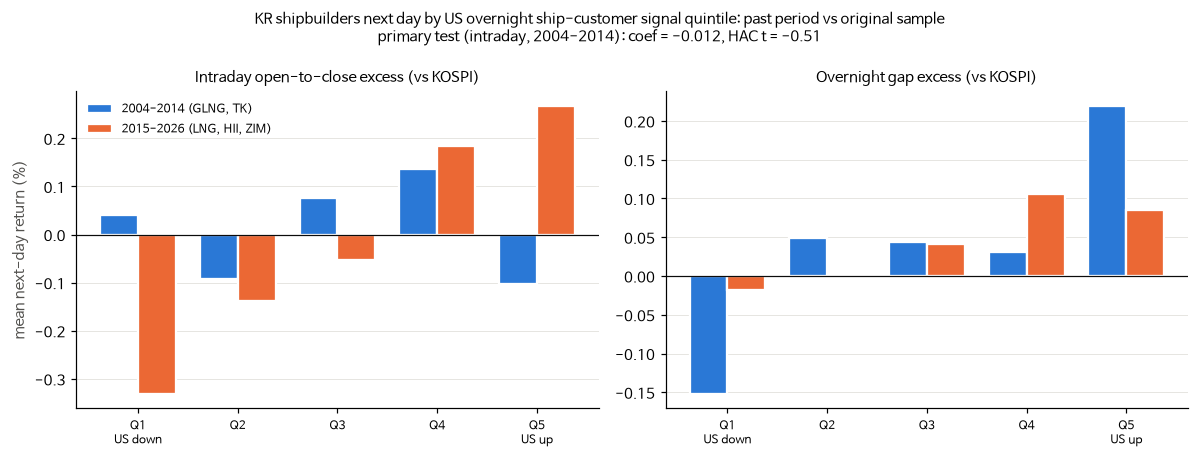

,검정,p,사전 지정 판정
0,"주: F2 장중 us_ship (2004~2014, WTI)",0.6081,True
1,보조: F1 갭 us_ship,0.0741,False
2,보조: 종가 us_ship,0.6168,False
3,"보조: F2 장중 us_ship (2007-07~, Brent)",0.2713,False
4,"보조: F1 갭 us_ship (2007-07~, Brent)",0.0867,False
5,"보조: 종가 us_ship (2007-07~, Brent)",0.9756,False
6,보조: F2 장중 us_ship (점검 제외),0.3940,False
7,보조: F3 신호일 비용 후 평균 = 0,0.0000,False


작업 3 단계 C 검정 수 8개 → Bonferroni 기준 p < 0.00625. 판정은 사전 지정 단일 검정(주)으로만.


In [26]:
# ---- 3-C4. 그림 + 검정 수 ----
BLUE, ORANGE, INK, INK2, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e4e3df"
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(5); w = 0.38
for ax, col, ttl in [(axes[0], "ship_intra_ex", "Intraday open-to-close excess (vs KOSPI)"), (axes[1], "ship_gap_ex", "Overnight gap excess (vs KOSPI)")]:
    ax.bar(x - w / 2, QCMP[col], w, color=BLUE, edgecolor="white", linewidth=1.5, label="2004-2014 (GLNG, TK)", zorder=2)
    ax.bar(x + w / 2, QCMP[col + " (원래 2015~)"], w, color=ORANGE, edgecolor="white", linewidth=1.5, label="2015-2026 (LNG, HII, ZIM)", zorder=2)
    ax.axhline(0, color=INK, lw=0.8); ax.set_xticks(x); ax.set_xticklabels(["Q1\nUS down", "Q2", "Q3", "Q4", "Q5\nUS up"], fontsize=8)
    ax.set_title(ttl, fontsize=9.5); ax.grid(axis="y", color=GRID, lw=0.6, zorder=0); ax.set_axisbelow(True)
    for s_ in ["top", "right"]: ax.spines[s_].set_visible(False)
axes[0].set_ylabel("mean next-day return (%)", color=INK2)
axes[0].legend(fontsize=8, frameon=False, loc="upper left")
fig.suptitle("KR shipbuilders next day by US overnight ship-customer signal quintile: past period vs original sample\n"
             f"primary test (intraday, 2004-2014): coef = {bJ:.3f}, HAC t = {tJ:.2f}", fontsize=10)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_ext2_hist_quintiles.png", bbox_inches="tight"); plt.show()

TT3 = pd.DataFrame([
    {"검정": "주: F2 장중 us_ship (2004~2014, WTI)", "p": T3C_main.loc[("ship_intra_ex", "us_ship"), "p"], "사전 지정 판정": True},
    {"검정": "보조: F1 갭 us_ship", "p": T3C_main.loc[("ship_gap_ex", "us_ship"), "p"], "사전 지정 판정": False},
    {"검정": "보조: 종가 us_ship", "p": T3C_main.loc[("ship_cc_ex", "us_ship"), "p"], "사전 지정 판정": False},
    {"검정": "보조: F2 장중 us_ship (2007-07~, Brent)", "p": T3C_brent.loc[("ship_intra_ex", "us_ship"), "p"], "사전 지정 판정": False},
    {"검정": "보조: F1 갭 us_ship (2007-07~, Brent)", "p": T3C_brent.loc[("ship_gap_ex", "us_ship"), "p"], "사전 지정 판정": False},
    {"검정": "보조: 종가 us_ship (2007-07~, Brent)", "p": T3C_brent.loc[("ship_cc_ex", "us_ship"), "p"], "사전 지정 판정": False},
    {"검정": "보조: F2 장중 us_ship (점검 제외)", "p": T3C_exc.loc[("ship_intra_ex", "us_ship"), "p"], "사전 지정 판정": False},
    {"검정": "보조: F3 신호일 비용 후 평균 = 0", "p": float(r_.pvalues[0]), "사전 지정 판정": False}])
NT3 = len(TT3)
TT3.to_csv(f"{RES_DIR}/T3_C7_test_count.csv", index=False, encoding="utf-8-sig"); display(TT3)
print(f"작업 3 단계 C 검정 수 {NT3}개 → Bonferroni 기준 p < {0.05/NT3:.5f}. 판정은 사전 지정 단일 검정(주)으로만.")

---
### 3-D. 탐색적 진단: 작업 3의 실패는 '시기' 때문인가 '신호' 때문인가
결과를 살리려는 검정이 아니라 원인을 구분하려는 **탐색적 진단**임. **이 결과로 작업 1·3의 판정은 바꾸지 않음.**
- 신호: 작업 3과 동일 (GLNG·TK 로그수익률 평균 − S&P500, `align_us_to_kr`)
- 기간: 2015-01 ~ 2026-09-17 (원래 Part F 표본)
- 종속변수·회귀식·HAC lag·유가 통제: Part F 원래 설정과 동일 (조선 바스켓 4종목 − KOSPI, `ship_intra_ex ~ us_ship + spx + brent(BZ=F)`, HAC 5)
- **사전 판단 규칙**: 장중 us_ship 계수 > 0 이고 t > 1.96 이면 "시기 차이 가능성"(과거 신호도 최근엔 작동 → 과거 실패는 시기 탓), 아니면 "신호 특수성 가능성"(원래 결과는 LNG·HII·ZIM 신호에 특수).
- 시가 갭·종가 회귀는 참고로만 표시하고 판단에 쓰지 않음.

In [27]:
# ---- 3-D. 탐색적 진단: GLNG·TK 신호, 2015-01 ~ 2026-09-17, Part F 원래 식 ----
DG = CFG["us_signal"]["candidates"]                       # GLNG, TK (작업 3과 동일)
raw_dg = yf.download(list(DG), start=START, end=END, auto_adjust=True, progress=False)["Close"]
raw_dg.index = pd.to_datetime(raw_dg.index).tz_localize(None)
for t in DG: assert raw_dg[t].notna().sum() > 0, f"{t} 데이터 수신 실패"
dg_ret = np.log(raw_dg).apply(lambda s: s.dropna().diff()).reindex(raw_dg.index)
usk_dg = align_us_to_kr(dg_ret, CAL)
print("2015~ 한국 거래일 중 신호 있는 날:", {t: int(usk_dg[t].notna().sum()) for t in DG}, "/", len(CAL),
      "| yfinance 기간 내 첫날:", {t: str(raw_dg[t].first_valid_index().date()) for t in DG})
F_dg = B.copy()                                           # 원래 Part F 바스켓·KOSPI 초과수익 (작업 1에서 만든 B)
F_dg["us_ship"] = usk_dg[list(DG)].mean(axis=1, skipna=True)
F_dg["spx"] = usk["^GSPC"]; F_dg["brent"] = usk["BZ=F"]
rows = []
for target, lab in [("ship_intra_ex", "F2 장중 (진단 판단)"), ("ship_gap_ex", "(참고) F1 시가 갭"), ("ship_cc_ex", "(참고) 종가→종가")]:
    res = hac_ols(F_dg[target], F_dg[["us_ship", "spx", "brent"]])
    o = orig_f1.loc[(target, "us_ship")]
    h = T3C_main.loc[(target, "us_ship")]
    rows.append({"종속변수": lab,
                 "진단: GLNG·TK, 2015~2026 coef": res.params["us_ship"], "진단 t": res.tvalues["us_ship"], "진단 p": res.pvalues["us_ship"], "진단 N": int(res.nobs),
                 "원래: LNG·HII·ZIM, 2015~2026 coef": o["coef"], "원래 t": o["HAC t"],
                 "작업 3: GLNG·TK, 2004~2014 coef": h["coef"], "작업 3 t": h["HAC t"]})
T3D = pd.DataFrame(rows).set_index("종속변수")
T3D.to_csv(f"{RES_DIR}/T3_D1_diagnostic_signal_vs_period.csv", encoding="utf-8-sig"); display(T3D)
bD, tD = T3D.iloc[0]["진단: GLNG·TK, 2015~2026 coef"], T3D.iloc[0]["진단 t"]
print(f"진단 (장중 us_ship): coef = {bD:.4f}, t = {tD:.2f} ⇒ "
      + ("시기 차이 가능성" if (bD > 0 and tD > 1.96) else "신호 특수성 가능성")
      + "  ※ 탐색적 진단 — 작업 1·3 판정은 바꾸지 않음")
print("참고: 2015~ 두 신호의 상관 (원래 us_ship vs GLNG·TK us_ship):",
      round(float(pd.concat([F["us_ship"], F_dg["us_ship"]], axis=1).dropna().corr().iloc[0, 1]), 3))
# (참고, 판단에 쓰지 않음) 신호마다 변동성이 달라 계수 크기를 직접 비교할 수 없으므로 1표준편차당 장중 효과(bp)로 환산
sd_rows = []
for lab, s_, b_ in [("진단: GLNG·TK, 2015~2026", F_dg["us_ship"], bD),
                    ("원래: LNG·HII·ZIM, 2015~2026", F["us_ship"], T3D.iloc[0]["원래: LNG·HII·ZIM, 2015~2026 coef"]),
                    ("작업 3: GLNG·TK, 2004~2014", F_h["us_ship"], T3D.iloc[0]["작업 3: GLNG·TK, 2004~2014 coef"])]:
    sd_rows.append({"신호·기간": lab, "us_ship 일간 표준편차(%)": s_.std() * 100, "장중 coef": b_, "1σ당 장중 효과(bp)": b_ * s_.std() * 1e4})
T3D2 = pd.DataFrame(sd_rows).set_index("신호·기간")
T3D2.to_csv(f"{RES_DIR}/T3_D2_effect_per_sd.csv", encoding="utf-8-sig"); display(T3D2)

2015~ 한국 거래일 중 신호 있는 날: {'GLNG': 2782, 'TK': 2782} / 2875 | yfinance 기간 내 첫날: {'GLNG': '2015-01-02', 'TK': '2015-01-02'}


,"진단: GLNG·TK, 2015~2026 coef",진단 t,진단 p,진단 N,"원래: LNG·HII·ZIM, 2015~2026 coef",원래 t,"작업 3: GLNG·TK, 2004~2014 coef",작업 3 t
종속변수,,,,,,,,
F2 장중 (진단 판단),0.0231,1.8355,0.0664,2780,0.1029,3.6767,-0.0116,-0.5128
(참고) F1 시가 갭,0.0114,1.9861,0.0470,2780,0.0224,1.5384,0.0223,1.7858
(참고) 종가→종가,0.0348,2.6521,0.0080,2780,0.1252,4.2518,0.0121,0.5004


진단 (장중 us_ship): coef = 0.0231, t = 1.84 ⇒ 신호 특수성 가능성  ※ 탐색적 진단 — 작업 1·3 판정은 바꾸지 않음
참고: 2015~ 두 신호의 상관 (원래 us_ship vs GLNG·TK us_ship): 0.456


,us_ship 일간 표준편차(%),장중 coef,1σ당 장중 효과(bp)
신호·기간,,,
"진단: GLNG·TK, 2015~2026",3.3688,0.0231,7.7866
"원래: LNG·HII·ZIM, 2015~2026",1.8003,0.1029,18.5201
"작업 3: GLNG·TK, 2004~2014",2.6499,-0.0116,-3.0753
